# mtDSB x Age DE analysis (pydeseq2, LRT-free)

In [90]:
import scanpy as sc
import decoupler as dc
import pertpy as pt
sc.set_figure_params(figsize=(3, 3), frameon=False)
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
import warnings
warnings.filterwarnings("ignore")

def make_pseudobulk(adata, celltype, ct_col="celltype_merged",
                    sample_cols=("mouse_id","genotype","age"),
                    layer="counts"):
    ad = adata[adata.obs[ct_col] == celltype].copy()
    if layer in ad.layers:
        X = ad.layers[layer]
    else:
        X = ad.X
    if sparse.issparse(X):
        X = X.tocsr()

    # define samples as unique combinations of sample_cols
    meta = ad.obs.loc[:, sample_cols].astype(str)
    meta["sample_id"] = meta.apply(lambda r: "_".join(r.values), axis=1)

    # aggregate counts by sample_id
    sample_ids = meta["sample_id"].values
    uniq = pd.Index(np.unique(sample_ids), name="sample_id")
    # map each cell to column index
    col_index = pd.Series(pd.Categorical(sample_ids, categories=uniq)).cat.codes.values

    # build counts: genes x samples
    n_genes = ad.n_vars
    n_samp  = len(uniq)
    M = np.zeros((n_genes, n_samp), dtype=np.int64)
    # fast aggregate with group-by via numpy
    for s in range(n_samp):
        idx = np.where(col_index == s)[0]
        if len(idx)==0: 
            continue
        Xi = X[idx]
        M[:, s] = Xi.sum(axis=0).A.ravel() if sparse.issparse(Xi) else Xi.sum(axis=0)

    # sample metadata frame
    smd = uniq.to_frame(index=False)
    # split back columns
    parts = smd["sample_id"].str.split("_", expand=True)
    for i, c in enumerate(sample_cols):
        smd[c] = parts[i].values
    smd["condition"] = smd["condition"].astype("category")
    # age: keep both categorical and numeric versions handy
    smd["age"] = smd["age"].astype(str)
    smd["age_num"] = pd.to_numeric(smd["age"], errors="coerce")

    # gene names
    genes = ad.var_names.to_list()

    return pd.DataFrame(M, index=genes, columns=smd["sample_id"]), smd.set_index("sample_id")

# =======================
# mtDSB x Age DE analysis (pydeseq2, LRT-free)
# - Per-age simple effects: model vs control
# - Interaction proxy: delta-LFC between ages with z-test
# Requirements: pydeseq2, anndata, numpy, pandas
# Assumes: pb[ct] = (counts_df [genes x samples], meta_df indexed by sample_id with columns "condition","age")
# =======================

import os
import numpy as np
import pandas as pd
from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
from statsmodels.stats.multitest import multipletests

# ---------- utilities ----------
def _align(counts_df, meta_df):
    if not counts_df.columns.equals(meta_df.index):
        common = counts_df.columns.intersection(meta_df.index)
        if len(common) == 0:
            raise ValueError("No overlapping sample IDs between counts_df.columns and meta_df.index")
        counts_df = counts_df.loc[:, common]
        meta_df   = meta_df.loc[common]
    return counts_df, meta_df

def _to_anndata(counts_df, meta_df):
    X = counts_df.T.astype(np.int64)  # samples x genes
    ad = AnnData(X=X.values)
    ad.obs_names = X.index.astype(str)
    ad.var_names = counts_df.index.astype(str)
    ad.obs = meta_df.copy()
    return ad

def _prep_condition(mdf, condition_col="condition", ref_condition="control"):
    mdf = mdf.copy()
    mdf[condition_col] = mdf[condition_col].astype(str).str.strip()
    uniq = list(pd.unique(mdf[condition_col]))
    # ensure ref present (case-insensitive rescue)
    if ref_condition not in uniq:
        m = [u for u in uniq if u.lower() == ref_condition.lower()]
        if not m:
            raise ValueError(f"Reference '{ref_condition}' not present. Found: {uniq}")
        ref_condition = m[0]
    mdf[condition_col] = pd.Categorical(
        mdf[condition_col],
        categories=[ref_condition] + [u for u in uniq if u != ref_condition],
        ordered=True
    )
    return mdf, ref_condition

def _detect_case(mdf, condition_col="condition", ref_condition="control"):
    cats = list(mdf[condition_col].cat.categories)
    case_levels = [c for c in cats if c != ref_condition]
    if len(case_levels) == 0:
        raise ValueError("No case level found (only control present).")
    # if multiple, pick the first deterministically
    return case_levels[0]

# ---------- DE pieces ----------
def simple_effect_at_age(counts_df, meta_df, age_value,
                         condition_col="condition", ref_condition="control",
                         n_cpus=8):
    """Run model vs control at a single age using a 1-factor DESeq2 model."""
    counts_df, meta_df = _align(counts_df, meta_df)

    mask = meta_df["age"].astype(str).str.strip() == str(age_value)
    if mask.sum() < 2:
        raise ValueError(f"Not enough samples at age={age_value}")
    cdf = counts_df.loc[:, mask]
    mdf = meta_df.loc[mask].copy()

    mdf, ref_condition = _prep_condition(mdf, condition_col=condition_col, ref_condition=ref_condition)
    case_label = _detect_case(mdf, condition_col=condition_col, ref_condition=ref_condition)

    ad = _to_anndata(cdf, mdf)
    dds = DeseqDataSet(
        adata=ad,
        design_factors=[condition_col],  # ~ condition
        refit_cooks=True,
        inference=DefaultInference(n_cpus=n_cpus),
    )
    dds.deseq2()

    st = DeseqStats(dds, contrast=[condition_col, case_label, ref_condition], inference=DefaultInference(n_cpus=n_cpus))
    st.summary()
    res = st.results_df.copy()
    res = res.rename(columns={
        "log2FoldChange": f"log2FC_{case_label}_vs_{ref_condition}",
        "lfcSE":          f"lfcSE_{case_label}_vs_{ref_condition}",
        "pvalue":         f"pvalue_{case_label}_vs_{ref_condition}",
        "padj":           f"padj_{case_label}_vs_{ref_condition}",
    })
    res.attrs = {"contrast": f"{case_label} vs {ref_condition} @ age {age_value}",
                 "age": str(age_value),
                 "case": case_label,
                 "ref": ref_condition}
    return res

def combine_delta_lfc(res_a, res_b):
    """
    Given two result DataFrames for the same genes (different ages),
    compute delta-LFC and a z-test using SEs: z = (lfc_b - lfc_a)/sqrt(se_b^2 + se_a^2)
    Returns a merged DataFrame with delta stats and FDR.
    """
    # infer column stems
    lfc_col_a = [c for c in res_a.columns if c.startswith("log2FC_")][0]
    se_col_a  = [c for c in res_a.columns if c.startswith("lfcSE_")][0]
    lfc_col_b = [c for c in res_b.columns if c.startswith("log2FC_")][0]
    se_col_b  = [c for c in res_b.columns if c.startswith("lfcSE_")][0]

    df = pd.DataFrame(index=res_a.index.union(res_b.index))
    df[lfc_col_a] = res_a[lfc_col_a]
    df[se_col_a]  = res_a[se_col_a]
    df[lfc_col_b] = res_b[lfc_col_b]
    df[se_col_b]  = res_b[se_col_b]

    # drop genes missing in either
    df = df.dropna(subset=[lfc_col_a, se_col_a, lfc_col_b, se_col_b]).copy()

    # delta and z
    df["delta_log2FC"] = df[lfc_col_b] - df[lfc_col_a]
    df["se_delta"] = np.sqrt(np.square(df[se_col_a]) + np.square(df[se_col_b]))
    # guard against zeros
    df["se_delta"] = df["se_delta"].replace(0, np.nan)
    df = df.dropna(subset=["se_delta"])
    df["z"] = df["delta_log2FC"] / df["se_delta"]
    # two-sided p from normal
    from scipy.stats import norm
    df["p_delta"] = 2 * (1 - norm.cdf(np.abs(df["z"])))
    df["q_delta"] = multipletests(df["p_delta"], method="fdr_bh")[1]
    return df

# ---------- main runner ----------
def run_all(pb, condition_col="condition", outdir=None, n_cpus=8, save_csv=False):
    """
    pb: dict like {"Oligodendrocyte": (counts_df, meta_df), ...}
    For each cell type:
      - compute per-age simple effects (model vs control) for all ages present
      - compute pairwise delta-LFC interaction proxy for all age pairs
    Returns: results dict per cell type
    """
    if save_csv and outdir:
        os.makedirs(outdir, exist_ok=True)

    results = {}
    for ct, (counts_df, meta_df) in pb.items():
        # discover ages (preserve observed order)
        ages = list(pd.unique(meta_df["age"].astype(str).str.strip()))
        per_age = {}
        # run simple effects
        for a in ages:
            try:
                res = simple_effect_at_age(counts_df, meta_df, a,
                                           condition_col=condition_col,
                                           ref_condition="control",
                                           n_cpus=n_cpus)
                per_age[a] = res
                if save_csv and outdir:
                    res.to_csv(os.path.join(outdir, f"{ct.replace(' ','_')}_simple_effect_age_{a}.csv"))
            except Exception as e:
                per_age[a] = None
                print(f"[{ct}] simple-effect failed at age={a}: {e}")

        # delta-LFC interaction proxy (all unique pairs)
        deltas = {}
        age_pairs = []
        for i in range(len(ages)):
            for j in range(i+1, len(ages)):
                a, b = ages[i], ages[j]
                if per_age.get(a) is None or per_age.get(b) is None:
                    continue
                dtab = combine_delta_lfc(per_age[a], per_age[b])
                dtab.attrs = {"age_A": a, "age_B": b,
                              "note": "delta_log2FC = LFC(age_B) - LFC(age_A)"}
                deltas[(a,b)] = dtab
                age_pairs.append((a,b))
                if save_csv and outdir:
                    dtab.to_csv(os.path.join(outdir, f"{ct.replace(' ','_')}_deltaLFC_{a}_vs_{b}.csv"))

        results[ct] = {
            "simple_effects": per_age,   # dict age -> DE table
            "deltas": deltas,            # dict (ageA,ageB) -> delta table with q_delta
            "ages": ages,
            "age_pairs": age_pairs
        }

    return results



## Read data

In [230]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')

In [231]:
adata.X = adata.layers['counts']
adata.X = adata.X.astype(int)

In [237]:
glia_classes = [
    # --- Astrocytes ---
    "Telencephalon astrocytes",
    "Olfactory astrocytes",

    # --- Oligodendrocyte lineage ---
    "Mature oligodendrocytes",
    "Oligodendrocytes precursor cells",

    # --- Microglia ---
    "Microglia",
]

In [239]:
adata = adata[adata.obs.cell_class.isin(glia_classes)]

In [240]:
adata

View of AnnData object with n_obs × n_vars = 335167 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Perform pseudobulk

In [241]:
celltypes = adata.obs.cell_class.unique()
pb = {}   # dict: celltype -> (count_df, sample_metadata)
for ct in celltypes:
    pb[ct] = make_pseudobulk(adata, celltype=ct, ct_col = 'cell_class', sample_cols = ('sample_id', 'condition', 'age'))

## Perform DGE

In [242]:
results = run_all(pb, condition_col="condition", outdir=None, n_cpus=8, save_csv=False)

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.18 seconds.

Fitting dispersion trend curve...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.11 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition mtDSB vs control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  1182.305468        0.208897  0.145926  1.431532  0.152278   
9630013A20Rik  2105.138848        0.365869  0.269775  1.356202  0.175035   
A1cf              3.589109       -1.841412  1.147881 -1.604184  0.108673   
A2m             342.022173        1.038859  0.294281  3.530157  0.000415   
Aatf           1446.297850        0.127922  0.164387  0.778176  0.436465   
...                    ...             ...       ...       ...       ...   
Zswim9          235.080892       -0.150295  0.196322 -0.765556  0.443941   
Zup1            275.153589        0.054504  0.180005  0.302790  0.762050   
Zyx             691.700478        0.153414  0.237869  0.644950  0.518960   
Zzef1          1178.695495       -0.113610  0.130920 -0.867786  0.385511   
a                 2.834891       -1.652620  1.408721 -1.173135  0.240742   

                   pad

... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.34 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.11 seconds.

Fitting size factors...
... done in 0.00 seconds.



Log2 fold change & Wald test p-value: condition mtDSB vs control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik   919.619346        0.214450  0.185925  1.153418  0.248739   
9630013A20Rik  2192.784162       -0.193845  0.247698 -0.782584  0.433871   
A1cf              3.004649        1.498837  1.289822  1.162049  0.245215   
A2m             245.129928        0.061922  0.356558  0.173667  0.862127   
Aatf           1473.799822        0.102172  0.179104  0.570458  0.568367   
...                    ...             ...       ...       ...       ...   
Zswim9          210.174044       -0.073389  0.176310 -0.416253  0.677225   
Zup1            247.157990        0.121529  0.165756  0.733183  0.463447   
Zyx             723.786709       -0.123781  0.131590 -0.940655  0.346881   
Zzef1          1079.538590        0.101737  0.133969  0.759409  0.447608   
a                 1.322841        1.713283  1.805735  0.948801  0.342722   

                   pad

...

... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.22 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.12 seconds.

Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Log2 fold change & Wald test p-value: condition mtDSB vs control
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik   411.503575       -0.133353  0.188954 -0.705743  0.480348   
9630013A20Rik    51.188247        0.416654  0.396306  1.051343  0.293101   
A1cf              0.079560        0.572618  4.450717  0.128657  0.897629   
A2m            1541.485582        1.322683  0.642878  2.057438  0.039644   
Aatf            300.349754        0.092888  0.166805  0.556867  0.577618   
...                    ...             ...       ...       ...       ...   
Zswim9           98.905086       -0.022812  0.232677 -0.098043  0.921898   
Zup1            148.917616        0.073714  0.265802  0.277327  0.781529   
Zyx             188.738718        0.163536  0.255826  0.639245  0.522664   
Zzef1           365.409002       -0.136122  0.150355 -0.905335  0.365288   
a                 0.860713       -1.001060  2.034822 -0.491964  0.622745   

                   pad

... done in 0.18 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...


Log2 fold change & Wald test p-value: condition mtDSB vs control
                 baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  297.615705        0.146153  0.145171  1.006763  0.314049   
9630013A20Rik   24.582750        0.084309  0.429730  0.196190  0.844461   
A1cf             0.000000             NaN       NaN       NaN       NaN   
A2m            734.017821        0.678906  0.473108  1.434991  0.151290   
Aatf           269.309163        0.158944  0.167180  0.950736  0.341739   
...                   ...             ...       ...       ...       ...   
Zswim9          68.830959       -0.290135  0.241918 -1.199312  0.230407   
Zup1           109.258887        0.038648  0.218423  0.176942  0.859554   
Zyx            128.378709       -0.048261  0.212205 -0.227427  0.820092   
Zzef1          316.284782       -0.015262  0.180454 -0.084578  0.932597   
a                0.497704       -0.945239  2.866733 -0.329727  0.741606   

                   padj  
2610035D

... done in 0.24 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 0.11 seconds.



In [262]:
import numpy as np
import matplotlib.pyplot as plt

def plot_lfc_across_ages_grid(
    results,
    ct,
    genes,
    q=0.05,
    ncols=4,
    figsize=(16, 9),
    sharey=True,
    fontsize_base=13
):
    """
    Plot log2FC across ages for multiple genes in subplots for a given cell type.
    Red dots = padj < q, grey = non-significant.
    Shared y-axis and increased text sizes for clarity.
    """
    ages = results[ct]["ages"]
    try:
        ages = sorted(ages, key=lambda x: float(x))
    except Exception:
        ages = sorted(ages)

    n_genes = len(genes)
    nrows = int(np.ceil(n_genes / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=figsize,
        sharex=True,
        sharey=sharey,
        constrained_layout=True
    )
    axes = np.ravel(axes)

    for i, gene in enumerate(genes):
        ax = axes[i]
        lfc, padj = [], []

        for a in ages:
            res = results[ct]["simple_effects"].get(a)
            if res is not None and gene in res.index:
                lfc_col = next(c for c in res.columns if c.startswith("log2FC_"))
                padj_col = next(c for c in res.columns if c.startswith("padj_"))
                lfc.append(res.loc[gene, lfc_col])
                padj.append(res.loc[gene, padj_col])
            else:
                lfc.append(np.nan)
                padj.append(np.nan)

        sig_mask = np.array(padj) < q
        ax.plot(ages, lfc, lw=1.5, c="black", zorder=2)
        ax.scatter(
            ages, lfc,
            c=["red" if s else "grey" for s in sig_mask],
            s=60, zorder=3
        )
        ax.axhline(0, ls="--", c="0.4", lw=1.0, zorder=1)

        # larger fonts for readability
        ax.set_title(gene, fontsize=fontsize_base, pad=6)
        ax.tick_params(axis='x', labelrotation=45, labelsize=fontsize_base - 2)
        ax.tick_params(axis='y', labelsize=fontsize_base - 2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # global labels — offset + larger text
    fig.suptitle(f"{ct}: log₂FC (mtDSB vs control) across ages",
                 fontsize=fontsize_base + 3, y=1.05, fontweight="bold")
    fig.text(0.5, -0.03, "Age (weeks)", ha="center", fontsize=fontsize_base + 1)
    fig.text(-0.04, 0.5, "log₂FC", va="center", rotation="vertical", fontsize=fontsize_base + 1)

    plt.subplots_adjust(bottom=0.12, left=0.10, right=0.98, top=0.93, wspace=0.25, hspace=0.35)
    plt.show()

In [263]:
results.keys()

dict_keys(['Mature oligodendrocytes', 'Telencephalon astrocytes', 'Microglia', 'Oligodendrocytes precursor cells', 'Olfactory astrocytes'])

2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:08 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

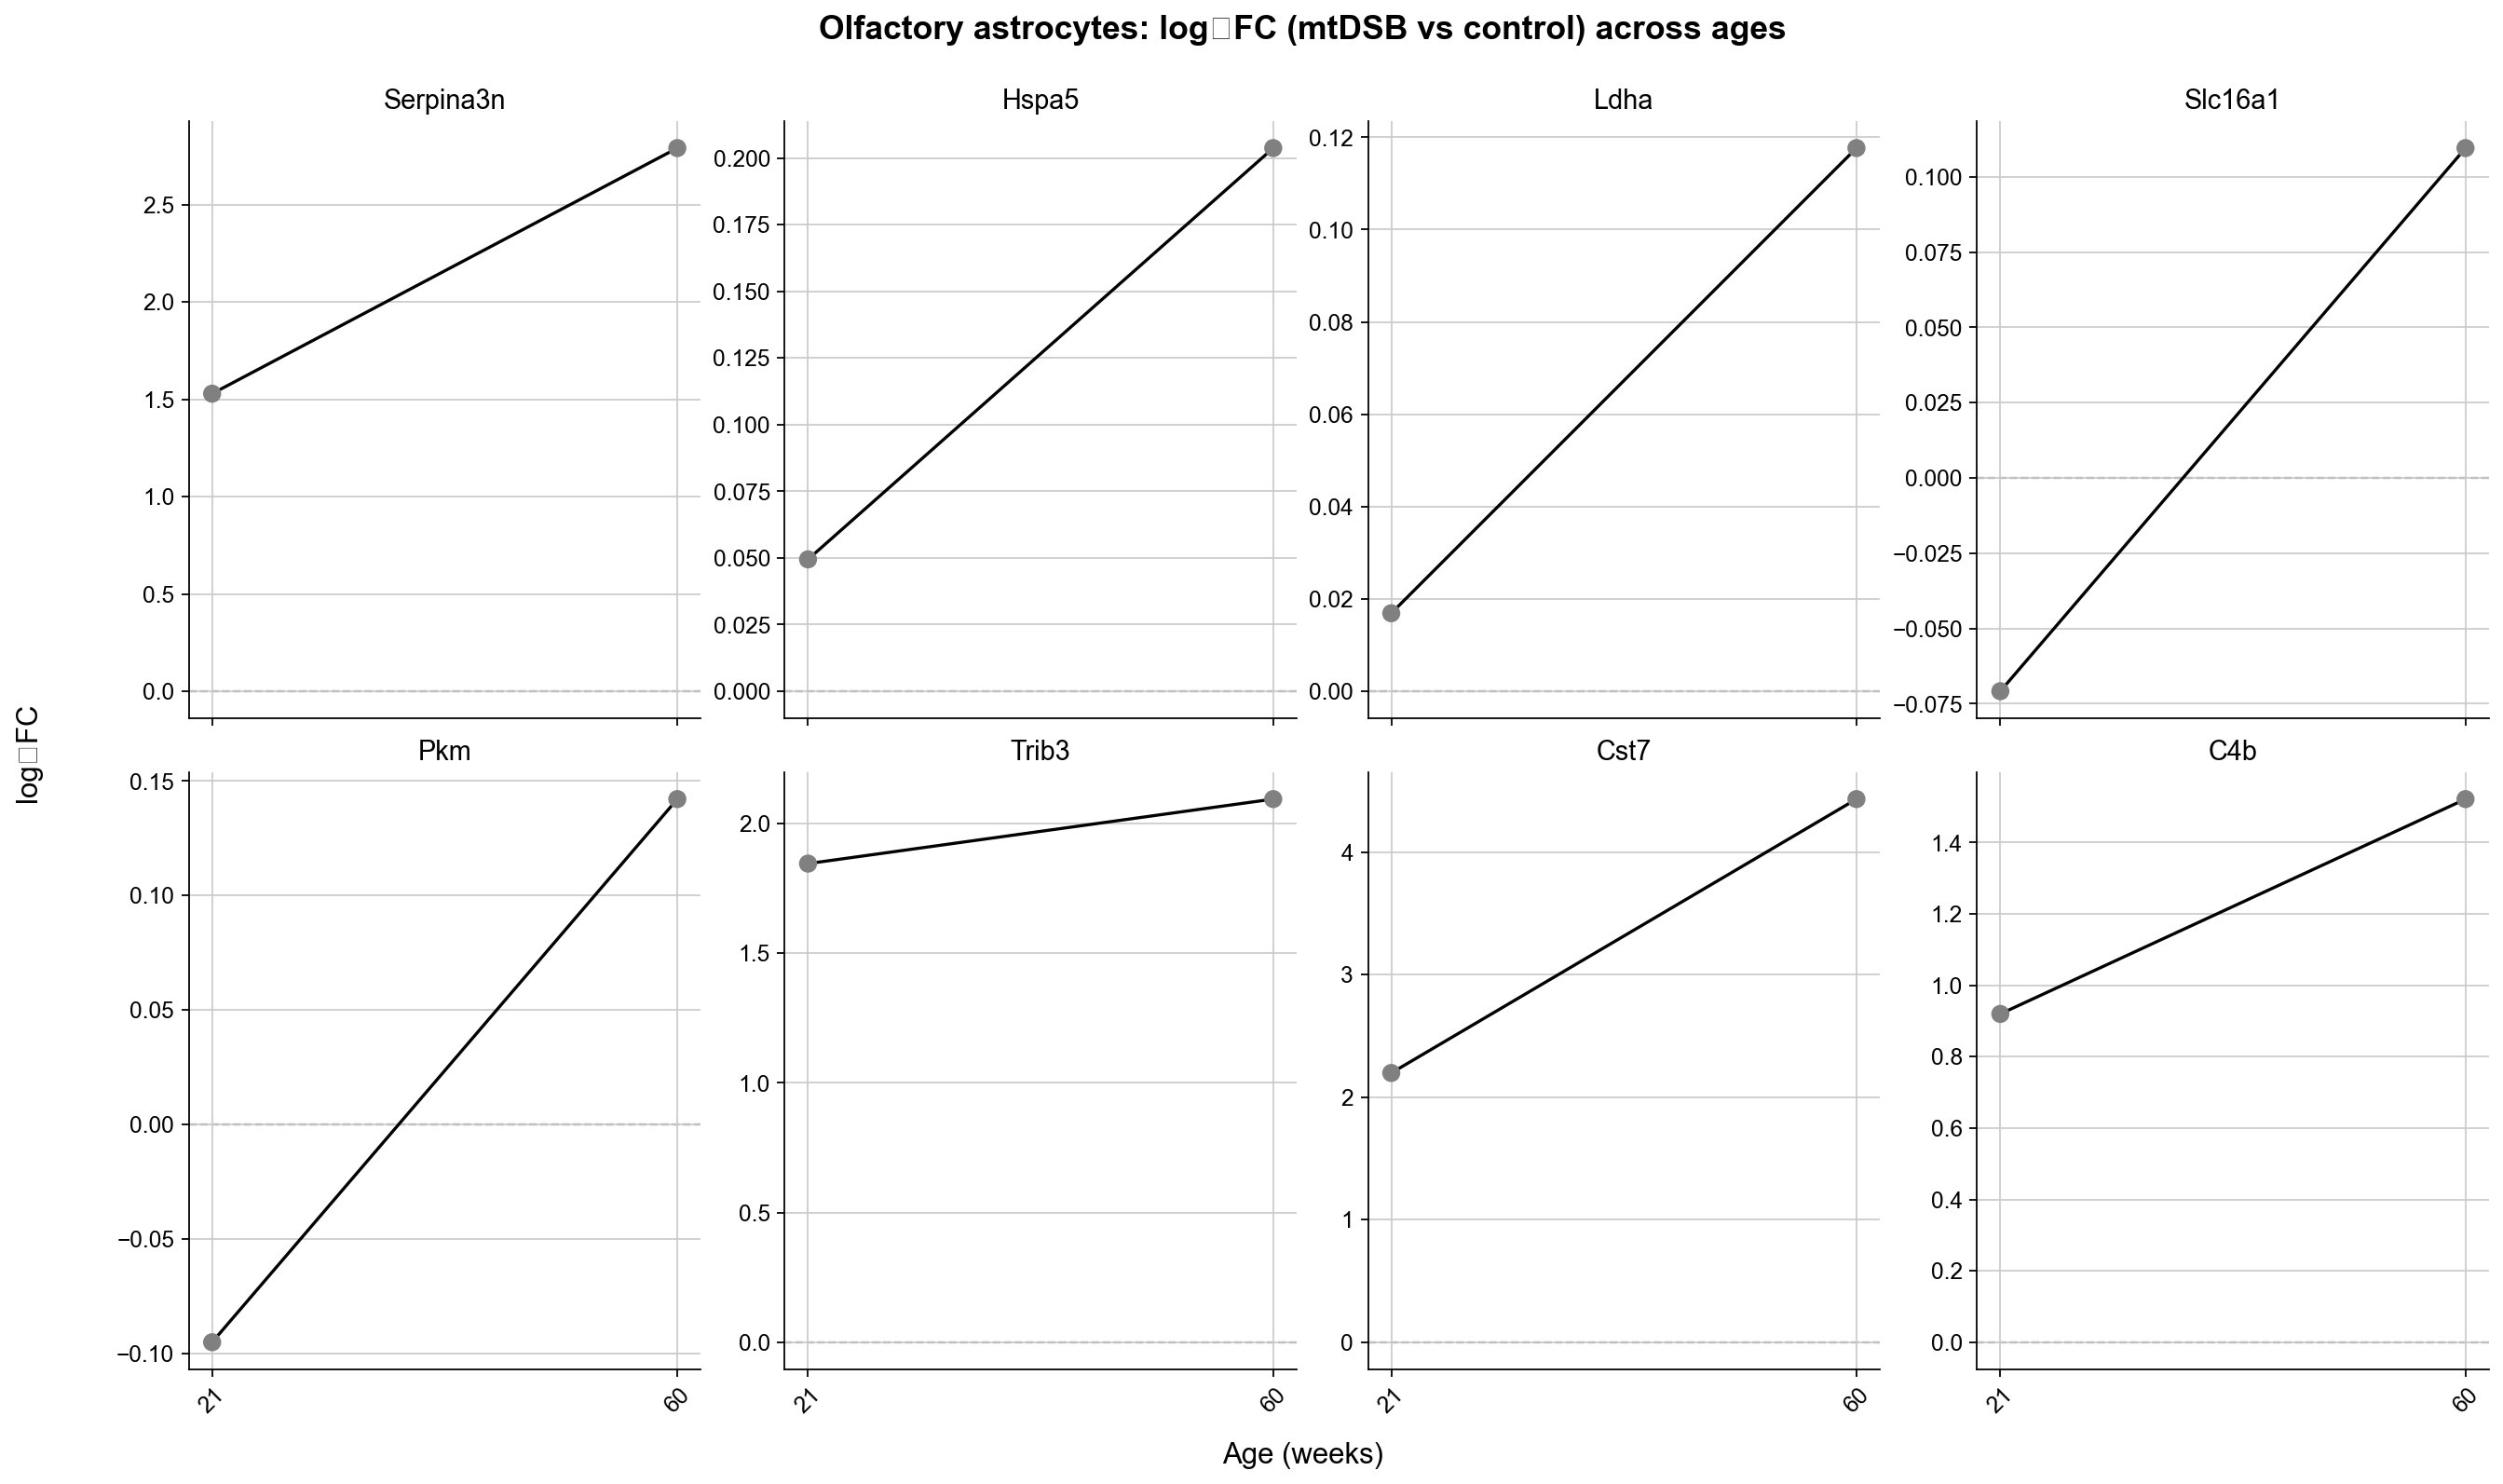

In [264]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "Olfactory astrocytes", genes, sharey=False)

2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:21 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

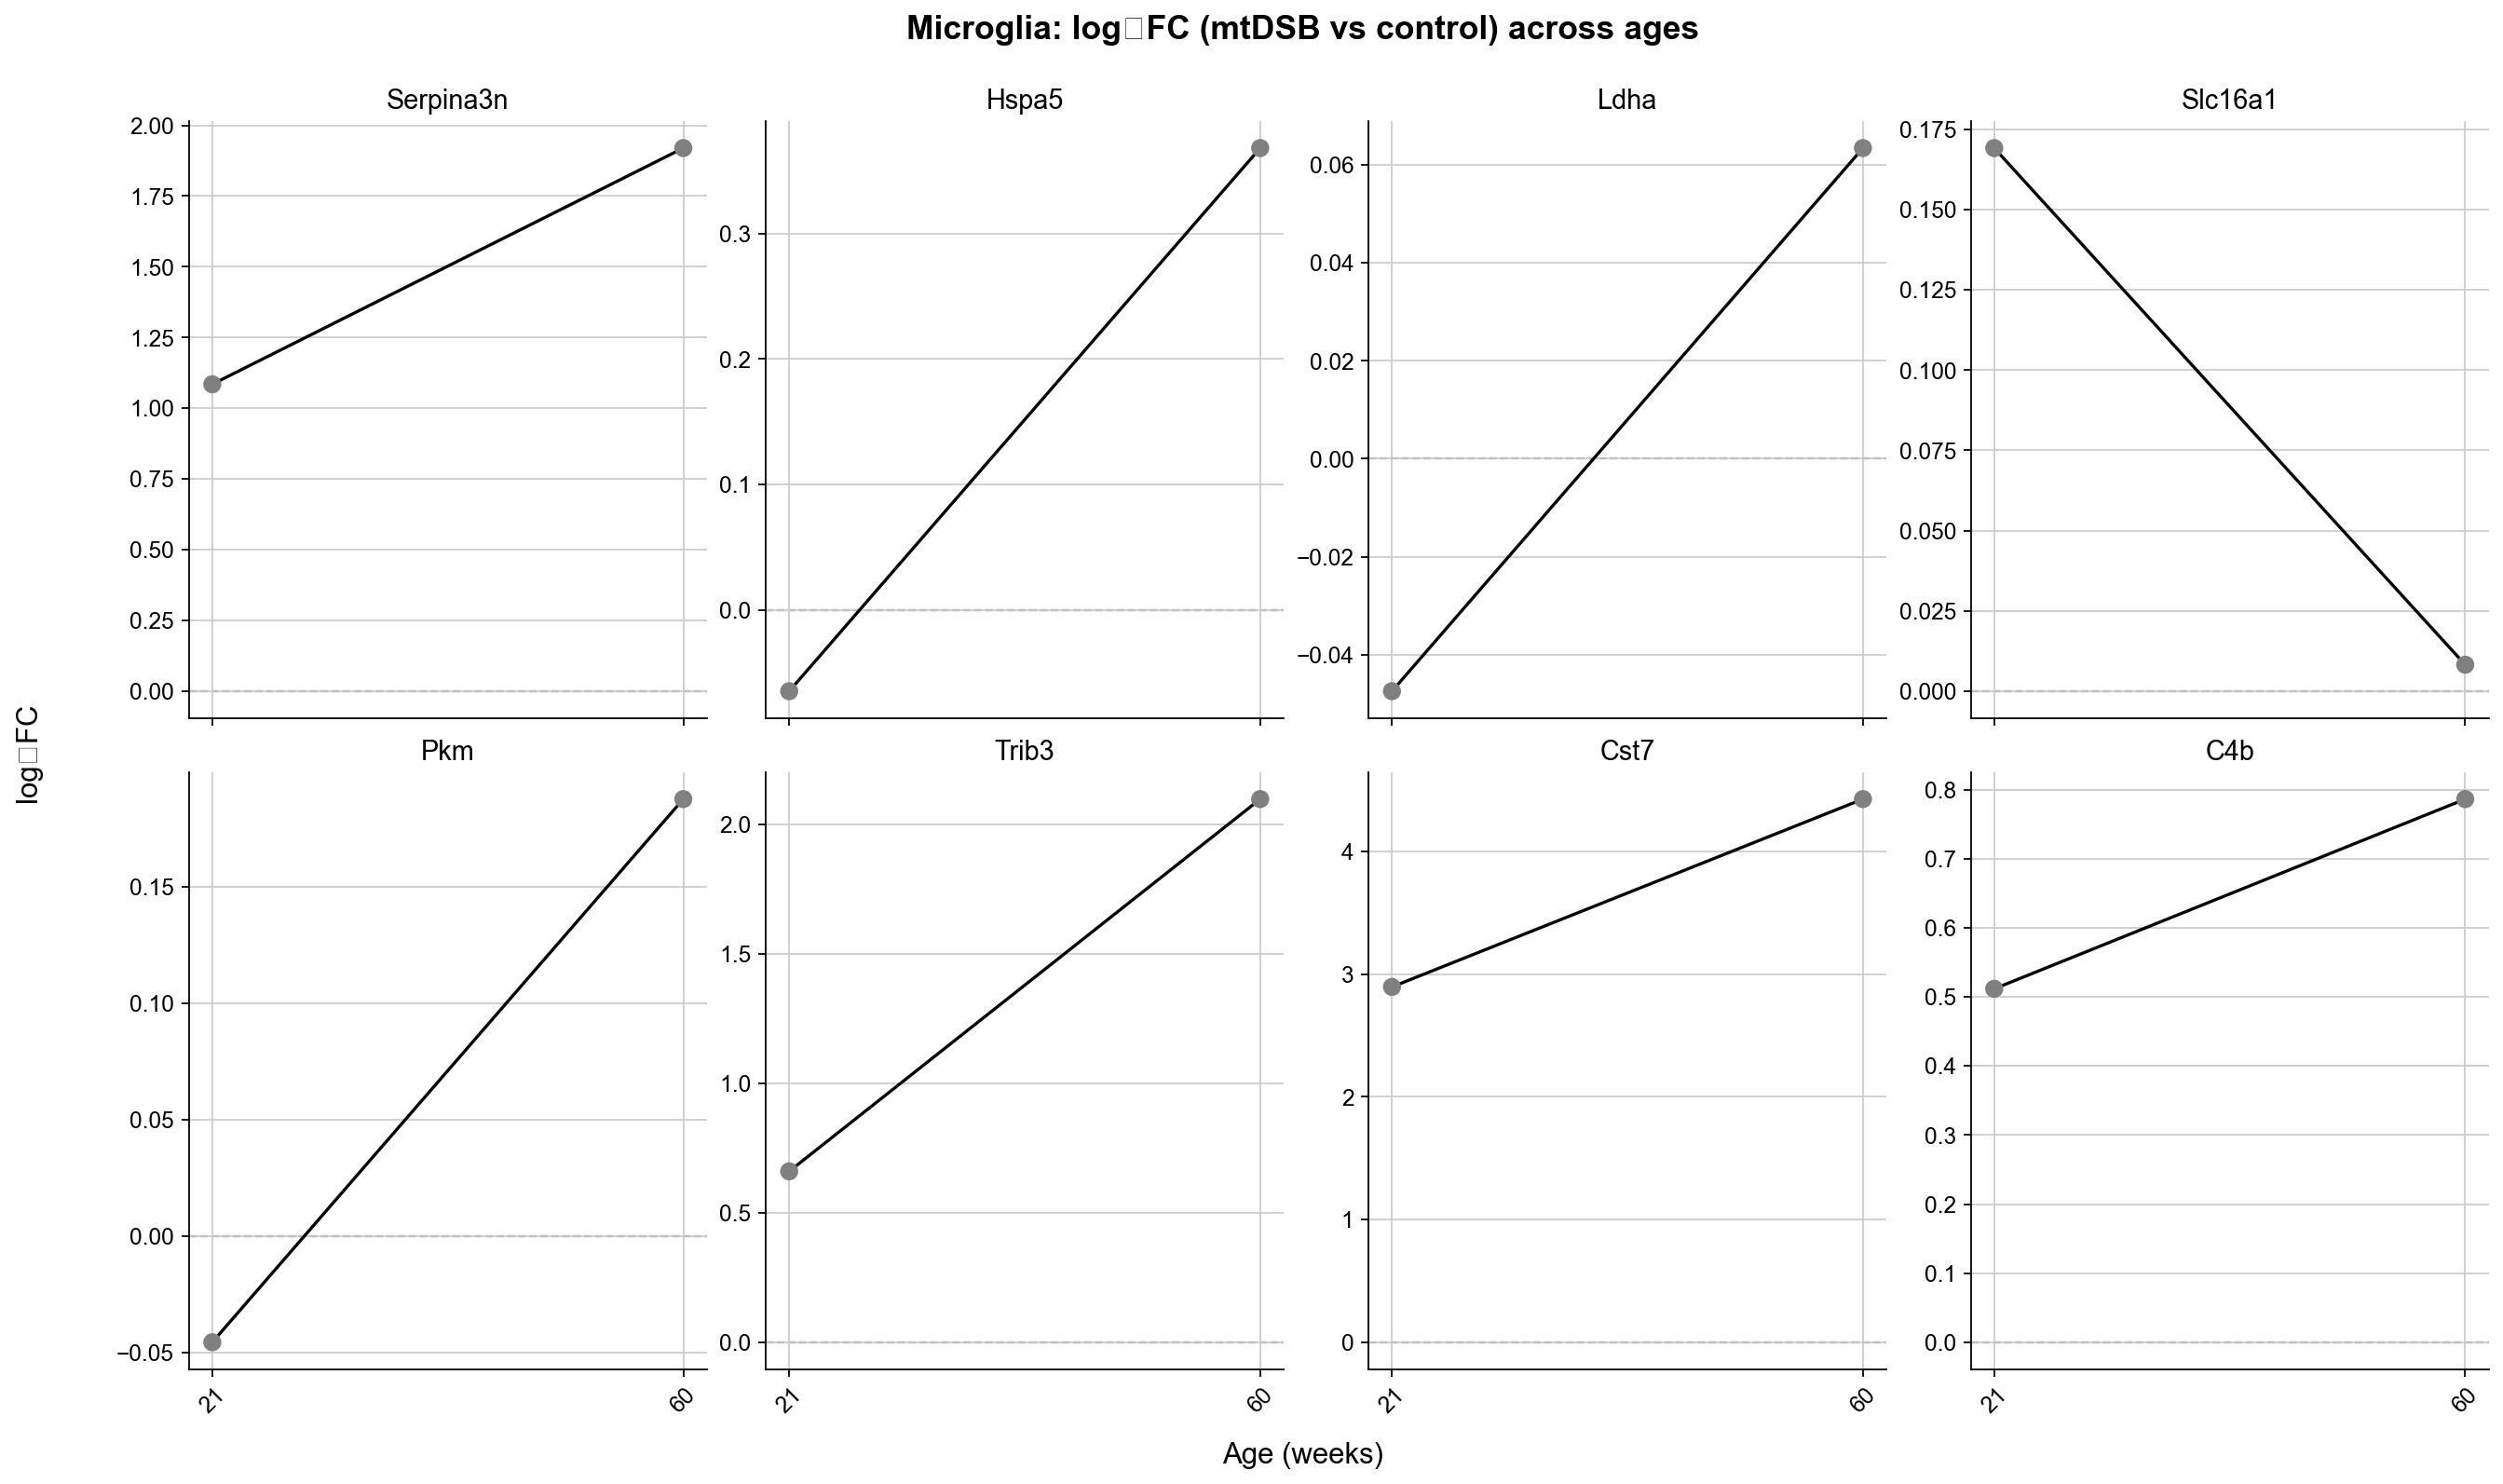

In [265]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "Microglia", genes, sharey=False)

2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:49:48 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

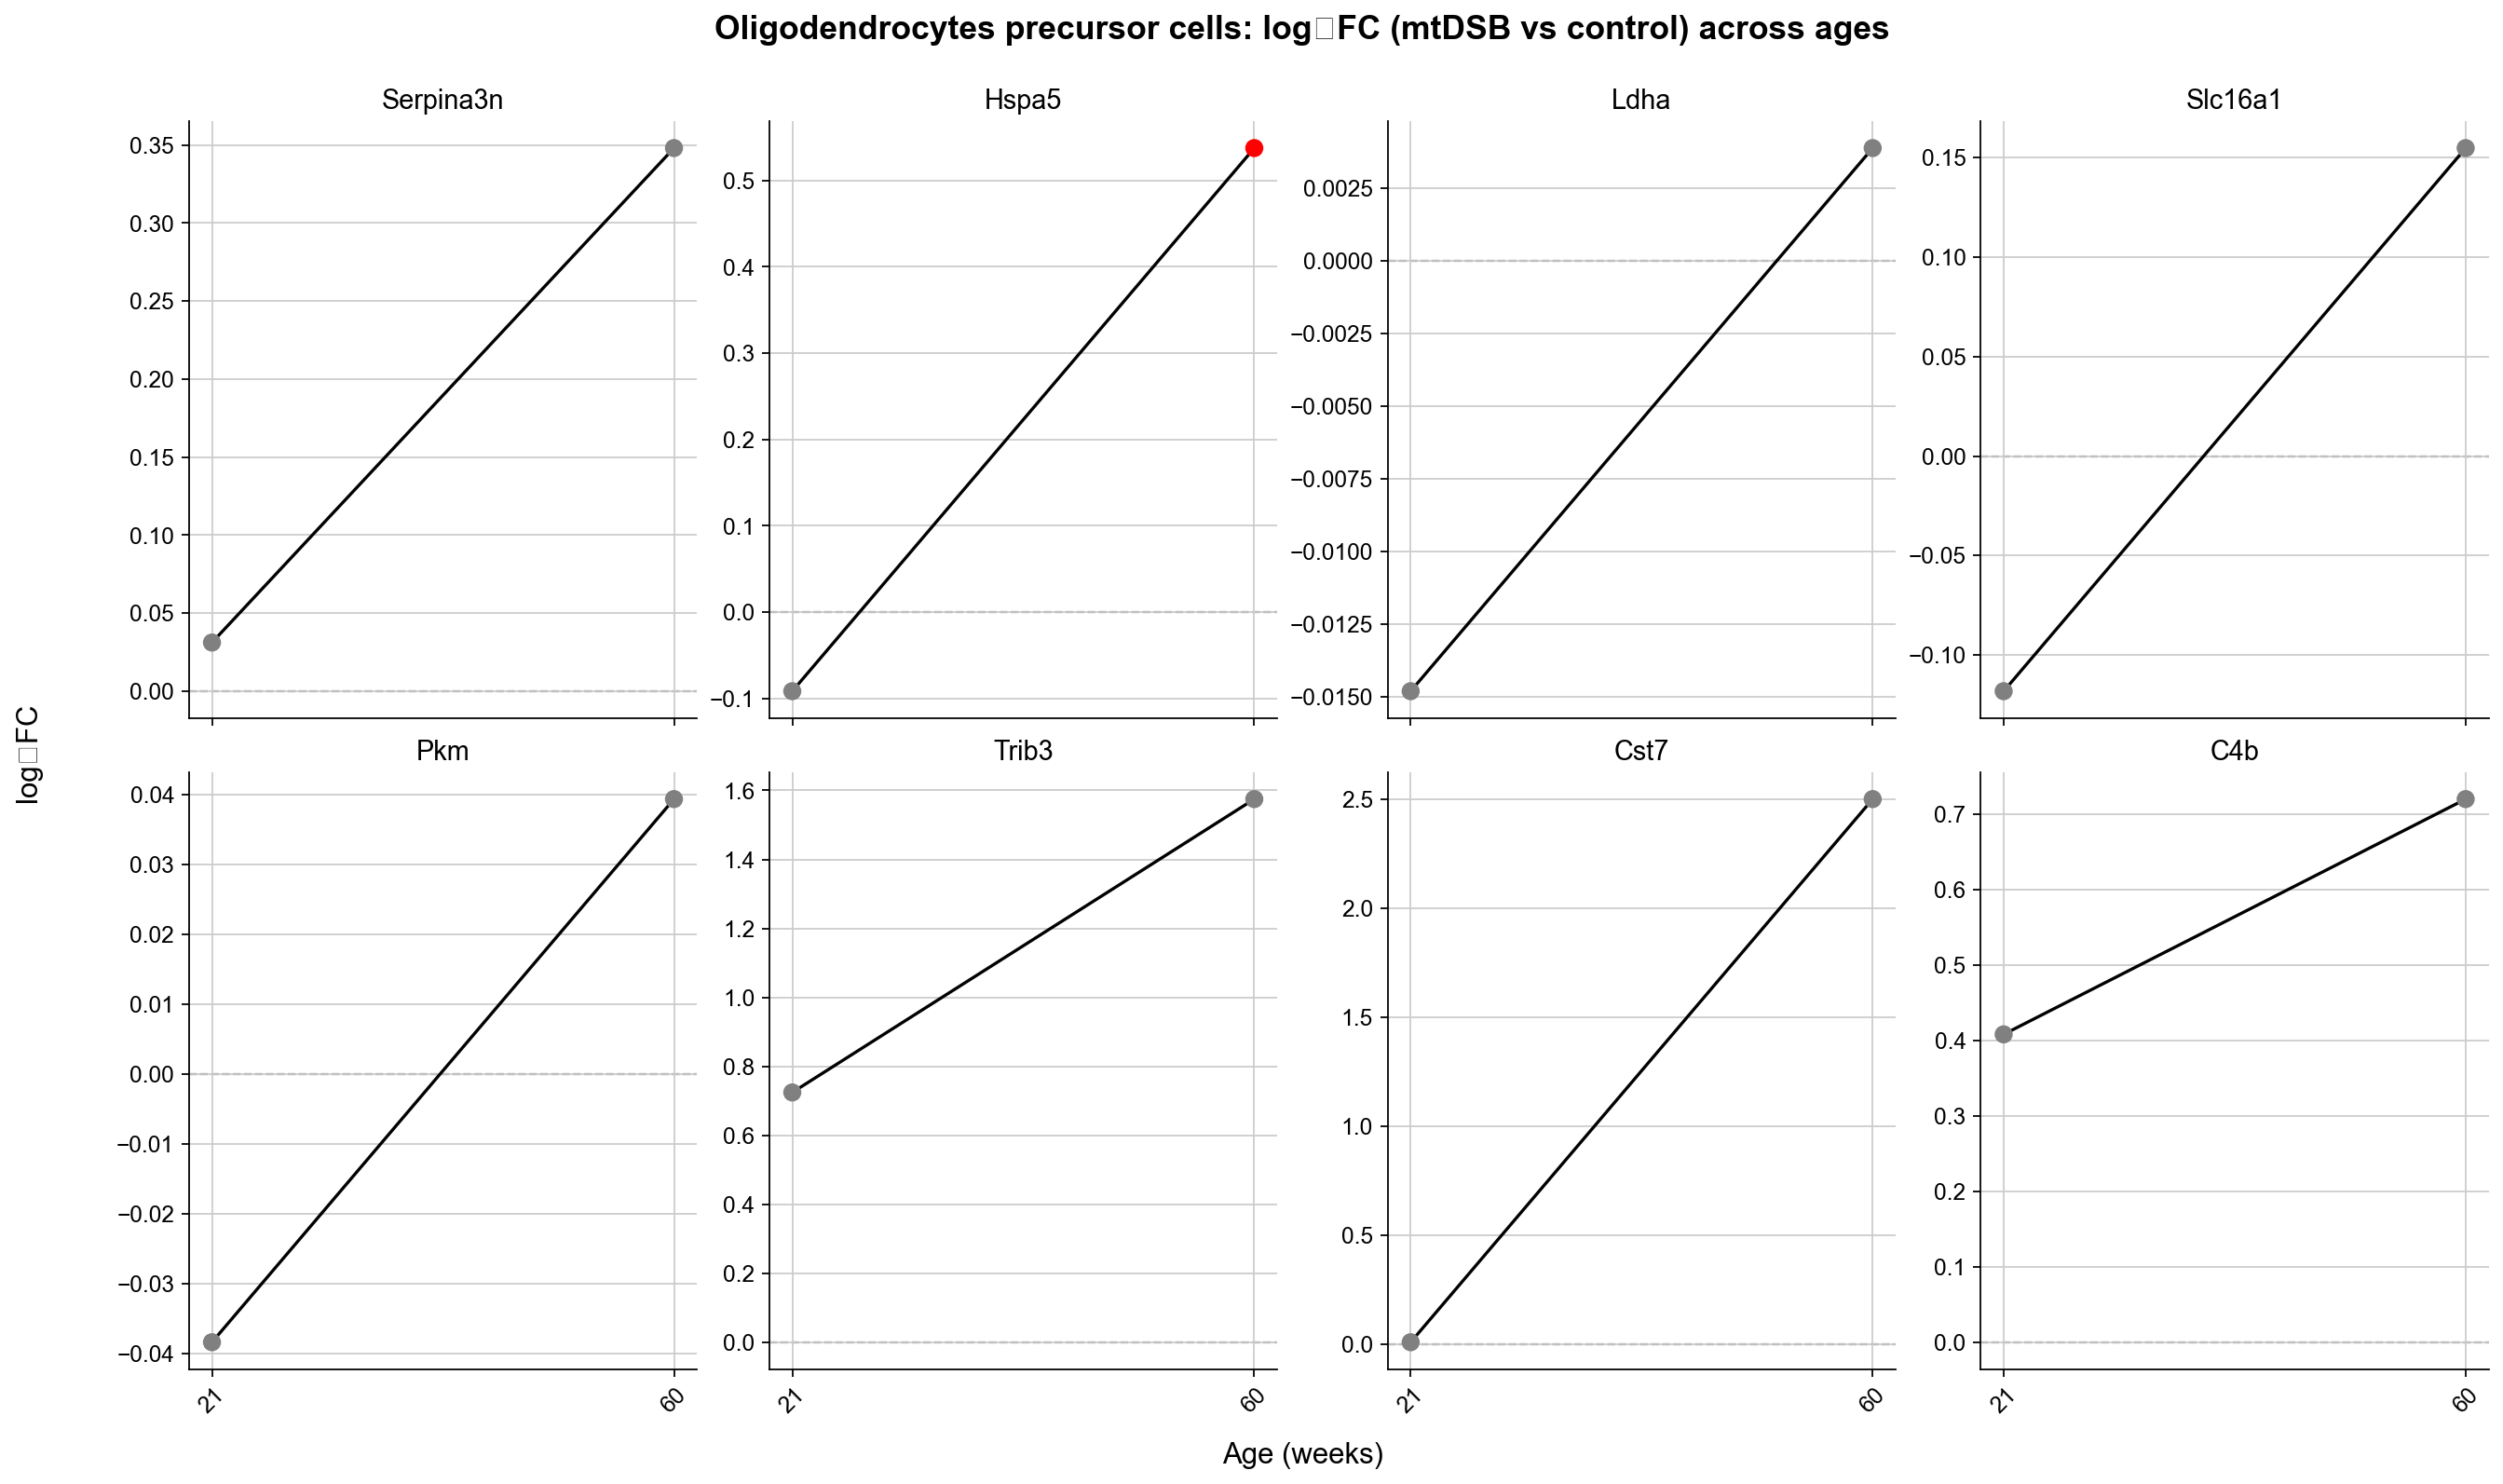

In [266]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "", genes, sharey=False)

2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:50:24 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

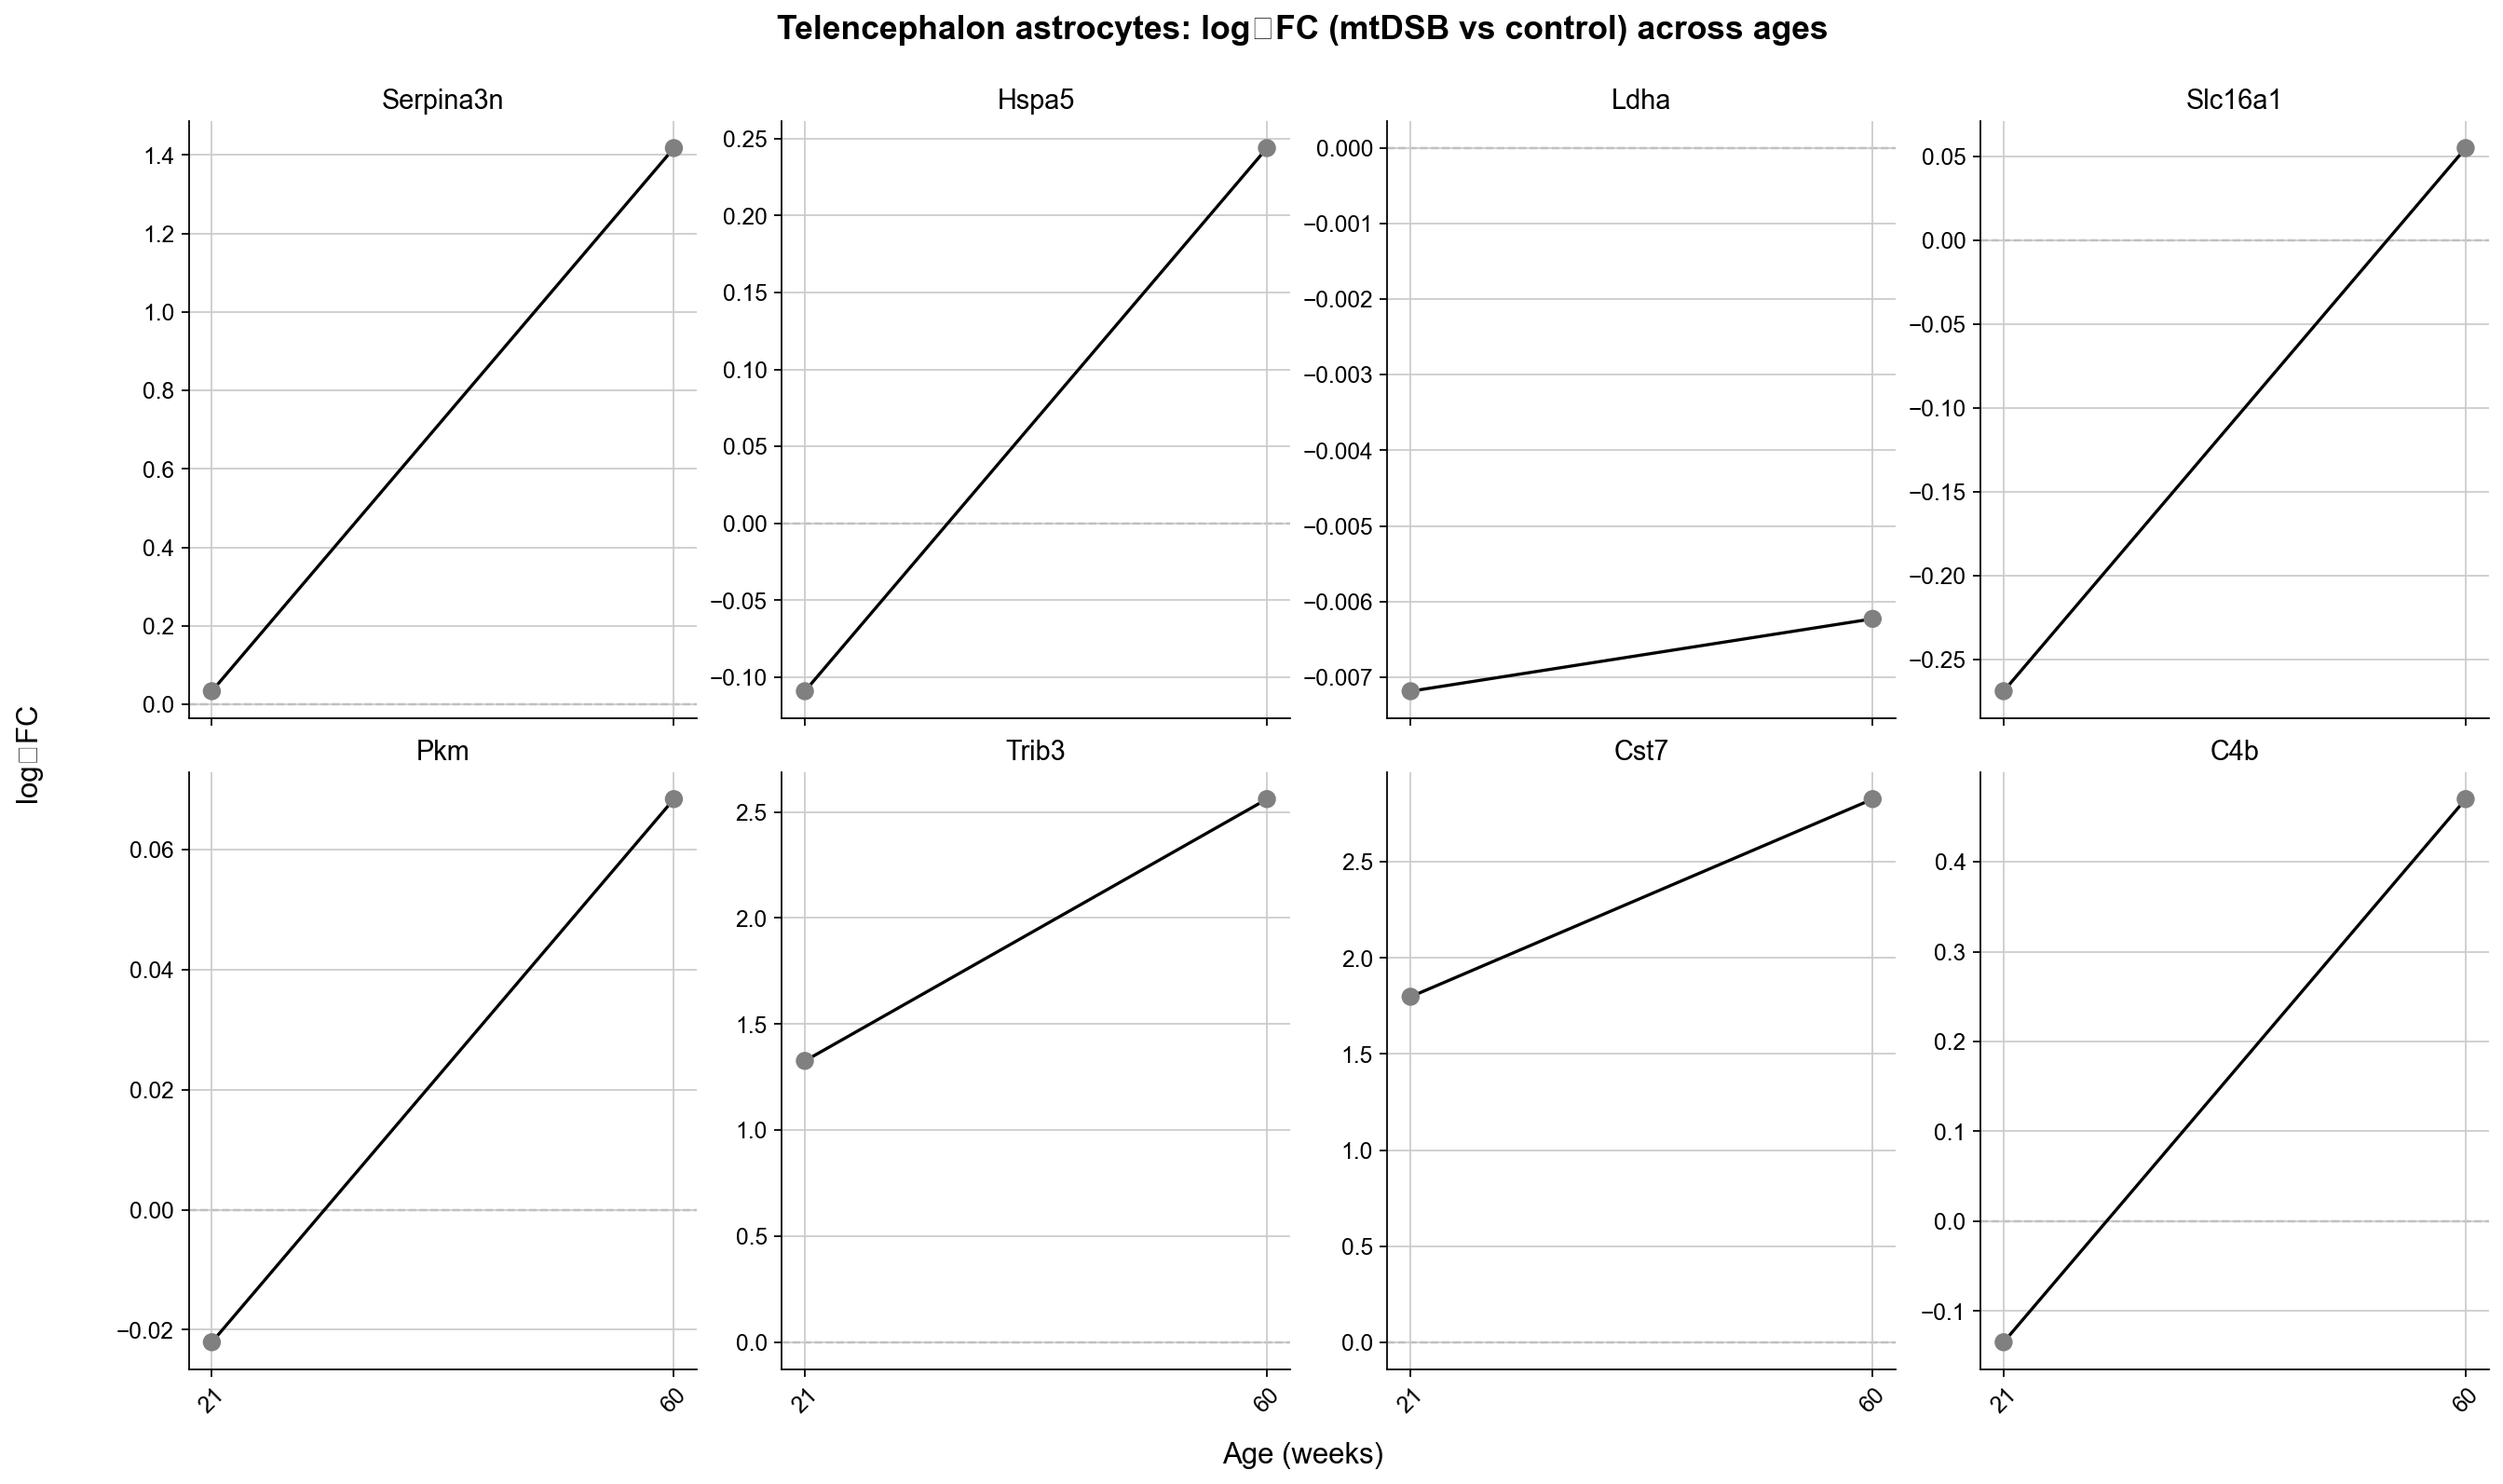

In [267]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_lfc_across_ages_grid(results, "Telencephalon astrocytes", genes, sharey=False)

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import math

def plot_expression_by_condition_grid(
    pb,
    ct,
    genes,
    norm=True,                 # CPM-normalize per sample
    q=None,                    # optional: highlight sig ages (not used here; keep for parity)
    ncols=4,                   # number of subplot columns
    sharey=True,               # share y-axis across genes for magnitude comparison
    figsize_per_panel=(4.0, 3.2),
    fontsize_base=13,
    suppress_warnings=True
):
    """
    Multi-panel plot of mean expression (pseudobulk) across ages for each condition.

    pb: dict-like, pb[ct] = (counts_df [genes x samples], meta_df [samples x meta])
    ct: cell class key present in pb
    genes: list of gene symbols to plot
    norm: if True, CPM-normalize per-sample library size before group averaging
    sharey: if True, use shared y-axis across all gene subplots
    """

    if suppress_warnings:
        warnings.filterwarnings("ignore")

    counts_df, meta_df = pb[ct]
    # keep only genes that exist
    genes_present = [g for g in genes if g in counts_df.index]
    missing = sorted(set(genes) - set(genes_present))
    if missing:
        print(f"Skipping missing genes ({len(missing)}): {', '.join(missing[:8])}" + ("..." if len(missing)>8 else ""))

    if len(genes_present) == 0:
        print("No requested genes found in counts_df.")
        return

    # Build long table for requested genes
    # sample-wise counts and metadata
    dat = counts_df.loc[genes_present].T  # samples x genes
    df = dat.stack().reset_index()
    df.columns = ["sample", "gene", "counts"]

    # attach meta
    meta = meta_df.copy()
    meta = meta.loc[df["sample"].unique()]  # ensure order/coverage
    # basic hygiene
    meta = meta.assign(
        age=meta["age"].astype(str).str.strip(),
        condition=meta["condition"].astype(str).str.strip()
    )
    df = df.merge(meta[["age", "condition"]], left_on="sample", right_index=True, how="left")

    # CPM normalize if requested
    if norm:
        lib_sizes = counts_df.sum(axis=0)  # per-sample library size
        df["cpm"] = df.apply(lambda r: (r["counts"] / lib_sizes.loc[r["sample"]]) * 1e6, axis=1)
        val_col = "cpm"
    else:
        val_col = "counts"

    # aggregate mean ± sem per condition × age × gene
    agg = (
        df.groupby(["gene", "condition", "age"], observed=True)[val_col]
          .agg(mean="mean", sem=lambda x: x.std(ddof=1)/np.sqrt(len(x)) if len(x)>1 else 0.0)
          .reset_index()
    )

    # sort ages numerically if possible
    try:
        age_order = sorted(agg["age"].unique(), key=lambda x: float(x))
    except Exception:
        age_order = sorted(agg["age"].unique())

    # figure layout
    n = len(genes_present)
    nrows = math.ceil(n / ncols)
    fig_w = max(ncols * figsize_per_panel[0], 6.0)
    fig_h = max(nrows * figsize_per_panel[1], 3.5)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(fig_w, fig_h),
        sharex=True,
        sharey=sharey,
        constrained_layout=True
    )
    axes = np.ravel(axes)

    # If sharey=True, compute global y-limits from all panels for consistency
    ymins, ymaxs = [], []
    if sharey:
        for g in genes_present:
            sub = agg[agg["gene"] == g]
            if sub.empty:
                continue
            ymins.append((sub["mean"] - sub["sem"]).min())
            ymaxs.append((sub["mean"] + sub["sem"]).max())
        if ymins and ymaxs:
            y_min = 0 if norm else min(0, np.nanmin(ymins))
            y_max = np.nanmax(ymaxs) * 1.08
        else:
            y_min, y_max = None, None

    # per-plot drawing
    for i, g in enumerate(genes_present):
        ax = axes[i]
        sub = agg[agg["gene"] == g].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        # draw each condition line with error bars
        for cond, grp in sub.groupby("condition", observed=True):
            grp = grp.set_index("age").reindex(age_order).reset_index()
            ax.errorbar(
                grp["age"], grp["mean"], yerr=grp["sem"],
                marker="o", capsize=4, lw=2.0, markersize=6, label=str(cond)
            )

        ax.axhline(0, ls="--", color="0.7", lw=1)  # helpful baseline (works for CPM too)
        ax.set_title(g, fontsize=fontsize_base, pad=6)
        ax.tick_params(axis="x", labelrotation=45, labelsize=fontsize_base-2)
        ax.tick_params(axis="y", labelsize=fontsize_base-2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # set shared y limits if requested
        if sharey and (y_min is not None) and (y_max is not None):
            ax.set_ylim(y_min, y_max)

        # lightweight legend per first subplot only
        if i == 0:
            ax.legend(frameon=False, fontsize=fontsize_base-2, title="Condition", title_fontsize=fontsize_base-2)
        else:
            ax.legend().remove()

    # hide unused panels
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    # global labels offset away from plots
    units = "CPM" if norm else "counts"
    fig.suptitle(f"{ct}: mean {units} across ages by condition",
                 fontsize=fontsize_base+3, y=1.04, fontweight="bold")
    fig.text(0.5, -0.035, "Age (weeks)", ha="center", fontsize=fontsize_base+1)
    fig.text(-0.035, 0.5, f"Mean {units}", va="center", rotation="vertical", fontsize=fontsize_base+1)

    # extra margins so labels never overlap
    plt.subplots_adjust(bottom=0.14, left=0.11, right=0.99, top=0.93, wspace=0.25, hspace=0.35)
    plt.show()

2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-09 09:53:26 | [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If 

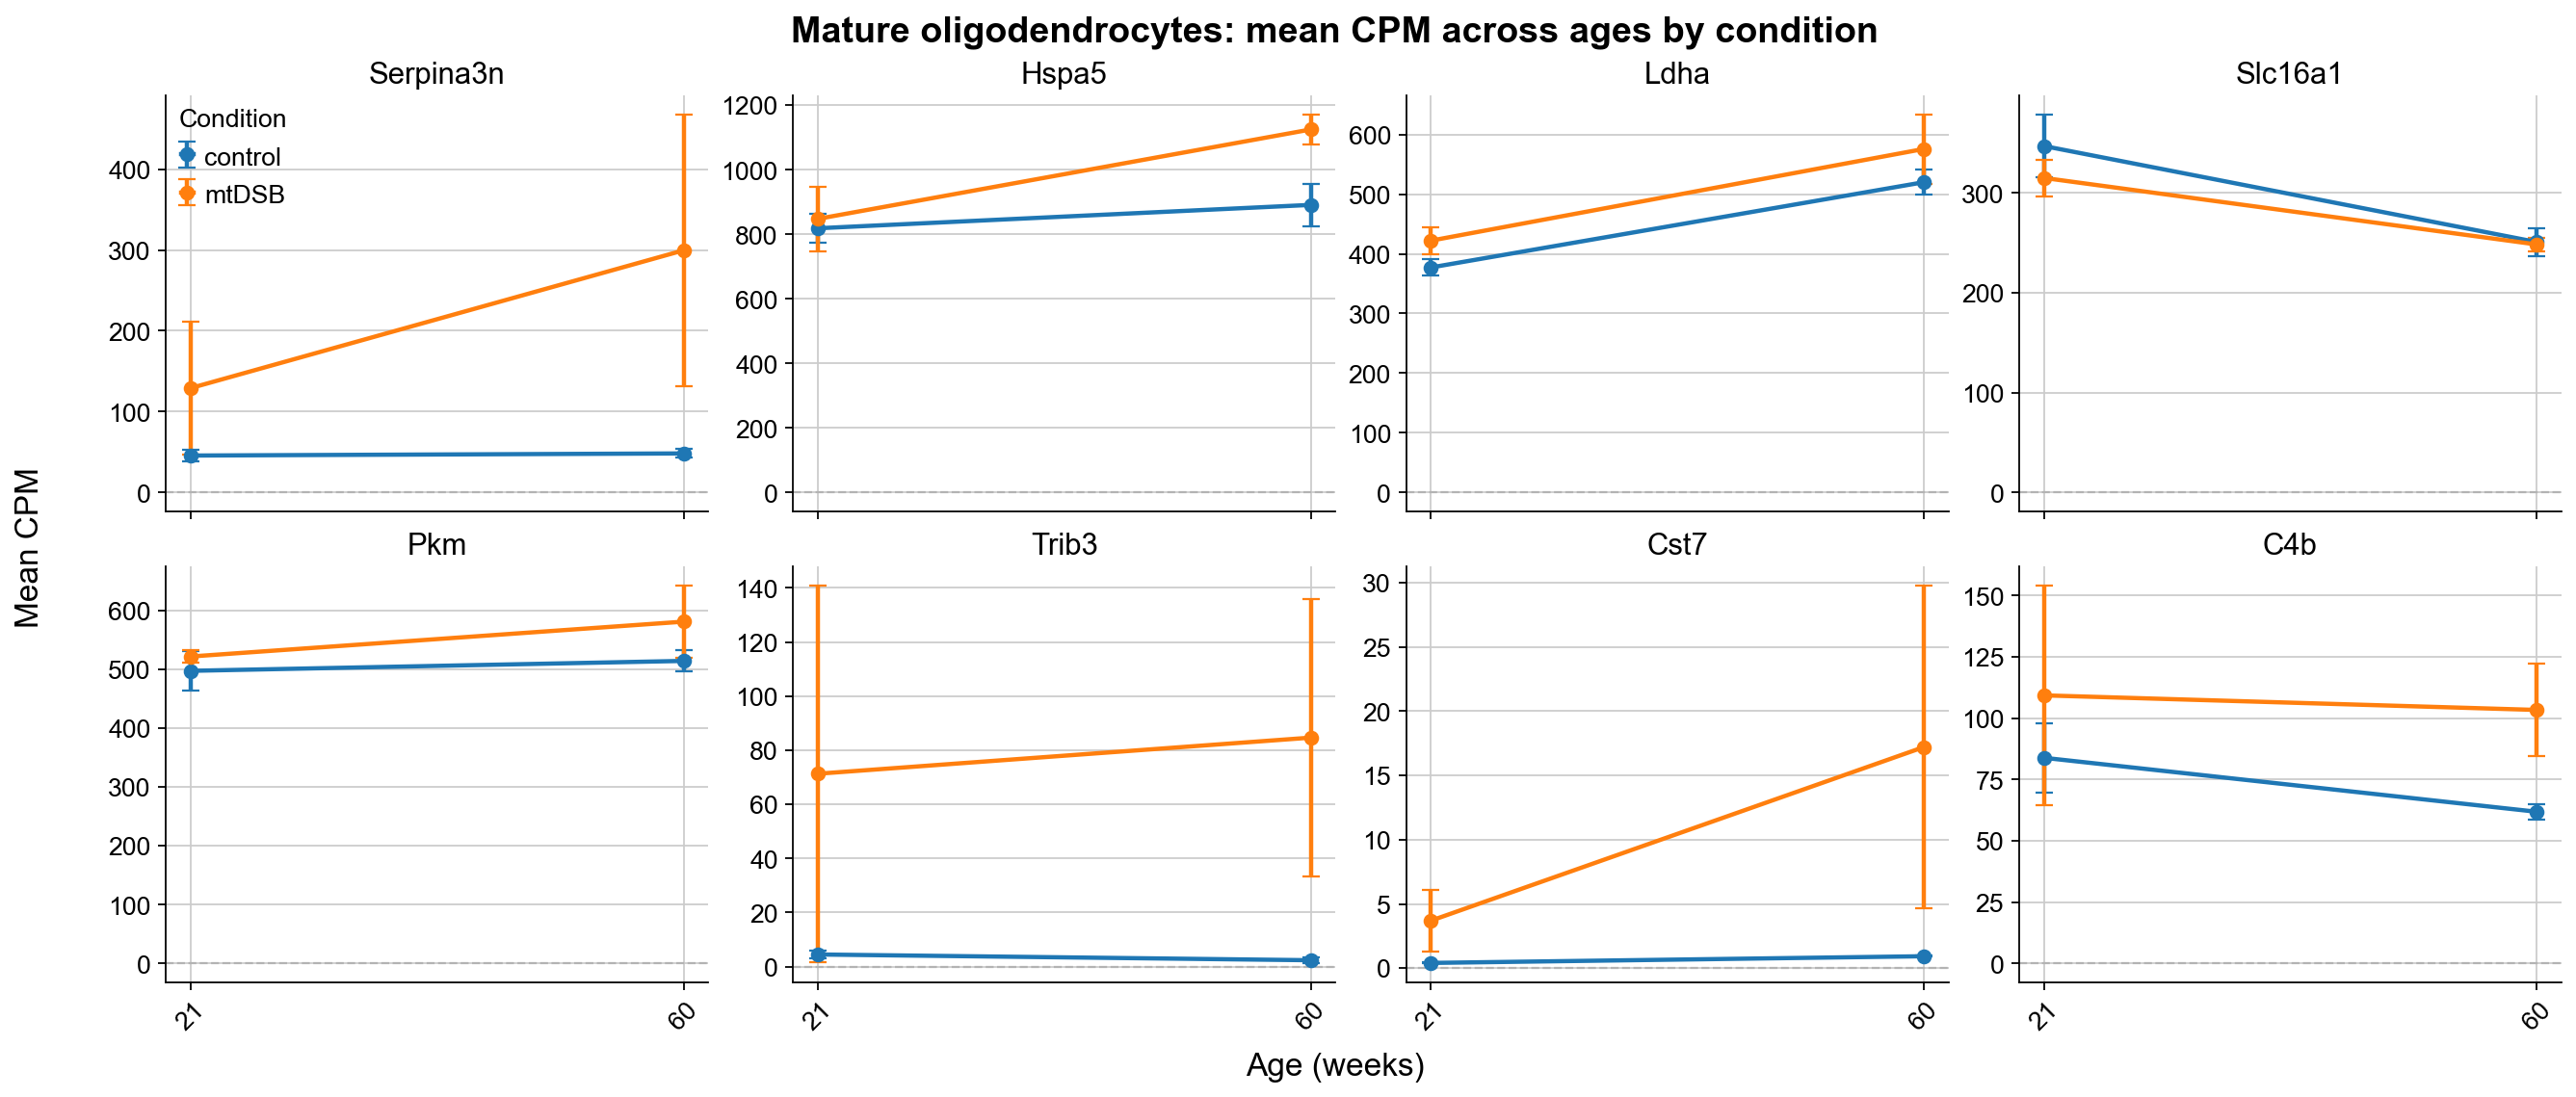

In [273]:
genes = ['Serpina3n','Hspa5','Ldha','Slc16a1','Pkm','Trib3','Cst7','C4b']
plot_expression_by_condition_grid(
    pb,
    ct="Mature oligodendrocytes",
    genes=genes,
    norm=True,        # CPM
    ncols=4,
    sharey=False,      # compare magnitudes across genes
    fontsize_base=14
)

In [274]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def volcano_clean(
    res_df,
    lfc_col="log2FC_mtDSB_vs_control",
    padj_col="padj_mtDSB_vs_control",
    title="mtDSB vs control (60 wks)",
    lfc_thr=1.0, q=0.05,
    label_top_fdr=10,            # how many best FDR genes to label
    label_top_abs_lfc=10,        # plus how many most extreme |LFC| to label
    max_labels=20,               # hard cap on labels
    highlight_genes=None,        # force-label these even if not in top sets
    figsize=(9,7), fontsize=13,
    pretty_print=True,           # <-- NEW: print a compact table
    to_csv_path=None             # <-- NEW: save that table as CSV if path given
):
    # --- prep ---
    df = (res_df.copy()
                 .replace([np.inf, -np.inf], np.nan)
                 .dropna(subset=[lfc_col, padj_col]))
    df["neglog10q"] = -np.log10(df[padj_col].clip(lower=1e-300))
    sig = (df[padj_col] < q) & (df[lfc_col].abs() >= lfc_thr)

    # ranks for selection/debug
    df["rank_fdr"] = df[padj_col].rank(method="dense")
    df["rank_abs_lfc"] = df[lfc_col].abs().rank(ascending=False, method="dense")

    # --- choose labels ---
    idx_fdr = df.sort_values(padj_col).head(label_top_fdr).index
    idx_lfc = df.reindex(df[lfc_col].abs().sort_values(ascending=False)
                         .head(label_top_abs_lfc).index).index
    pick = set(idx_fdr).union(set(idx_lfc))
    if highlight_genes:
        pick.update(set(df.index.intersection(highlight_genes)))
    if len(pick) > max_labels:
        pick = set(df.loc[list(pick)].sort_values("neglog10q", ascending=False)
                   .head(max_labels).index)

    # --- build pretty table of the picked genes ---
    picked_df = (df.loc[sorted(pick, key=lambda g: (df.at[g, padj_col], -abs(df.at[g, lfc_col]))) ,
                       [lfc_col, padj_col, "neglog10q", "rank_fdr", "rank_abs_lfc"]]
                   .rename(columns={
                       lfc_col: "log2FC",
                       padj_col: "padj",
                       "neglog10q": "-log10(FDR)"
                   }))
    picked_df.index.name = "gene"

    if pretty_print:
        # concise, aligned print
        print("\n=== Important genes (labeled on plot) ===")
        print(picked_df.round({"log2FC":3, "padj":3, "-log10(FDR)":2}).to_string())

    if to_csv_path:
        picked_df.to_csv(to_csv_path)

    # --- plot ---
    plt.figure(figsize=figsize, dpi=150)
    # background
    plt.scatter(df[lfc_col], df["-log10(FDR)"] if "-log10(FDR)" in df.columns else df["neglog10q"],
                s=16, alpha=0.35, color="lightgrey", label="not sig")
    # significant up/down
    up = df[sig & (df[lfc_col] > 0)]
    dn = df[sig & (df[lfc_col] < 0)]
    plt.scatter(up[lfc_col], up["neglog10q"], s=28, color="#d73027", label="Up (sig)")
    plt.scatter(dn[lfc_col], dn["neglog10q"], s=28, color="#4575b4", label="Down (sig)")

    # thresholds
    plt.axvline(+lfc_thr, ls="--", color="k", lw=1)
    plt.axvline(-lfc_thr, ls="--", color="k", lw=1)
    plt.axhline(-np.log10(q), ls="--", color="k", lw=1)

    plt.xlabel("log₂ fold change (mtDSB vs control)", fontsize=fontsize)
    plt.ylabel("-log₁₀(FDR)", fontsize=fontsize)
    plt.title(title, fontsize=fontsize+2, pad=10)

    # labels with repulsion/arrows
    texts = []
    try:
        from adjustText import adjust_text
        for g in picked_df.index:
            x, y = df.at[g, lfc_col], df.at[g, "neglog10q"]
            t = plt.text(x, y, g, fontsize=fontsize-3, va="bottom", ha="center")
            texts.append(t)
            plt.scatter([x],[y], s=40, edgecolor="black", linewidth=0.6, zorder=4)
        adjust_text(
            texts,
            only_move={'points':'y', 'text':'xy'},
            expand_points=(1.2, 1.4),
            expand_text=(1.1, 1.2),
            arrowprops=dict(arrowstyle="-", lw=0.8, color="0.25"),
        )
    except ImportError:
        for g in picked_df.index:
            x, y = df.at[g, lfc_col], df.at[g, "neglog10q"]
            dx = 0.15 if x >= 0 else -0.15
            dy = 0.25
            plt.annotate(
                g, xy=(x, y), xytext=(x+dx, y+dy),
                fontsize=fontsize-3,
                arrowprops=dict(arrowstyle="-", lw=0.8, color="0.25"),
                ha="center", va="bottom"
            )
            plt.scatter([x],[y], s=40, edgecolor="black", linewidth=0.6, zorder=4)

    plt.legend(frameon=False, fontsize=fontsize-3)
    plt.tight_layout()
    plt.show()

    # also return the table for downstream use
    return picked_df


=== Important genes (labeled on plot) ===
           log2FC   padj  -log10(FDR)  rank_fdr  rank_abs_lfc
gene                                                         
Pmch       -3.406  0.000         6.30       1.0           8.0
Gabra2      1.155  0.000         4.92       2.0         190.0
Mt2         0.694  0.000         4.53       3.0         487.0
Hcrt       -4.498  0.001         3.03       4.0           4.0
Gfap        1.254  0.006         2.24       5.0         159.0
Serpine1    3.166  0.009         2.05       6.0          12.0
Trh         1.552  0.009         2.05       6.0          98.0
Ccl3        2.859  0.026         1.58       7.0          16.0
Slc11a1     1.575  0.027         1.57       8.0          91.0
Id1         0.848  0.030         1.53       9.0         345.0
Itga5       1.812  0.037         1.43      10.0          59.0
Cercam     -0.591  0.046         1.34      11.0         633.0
Gpnmb       3.206  0.075         1.13      13.0          11.0
Trib3       5.097  0.080   

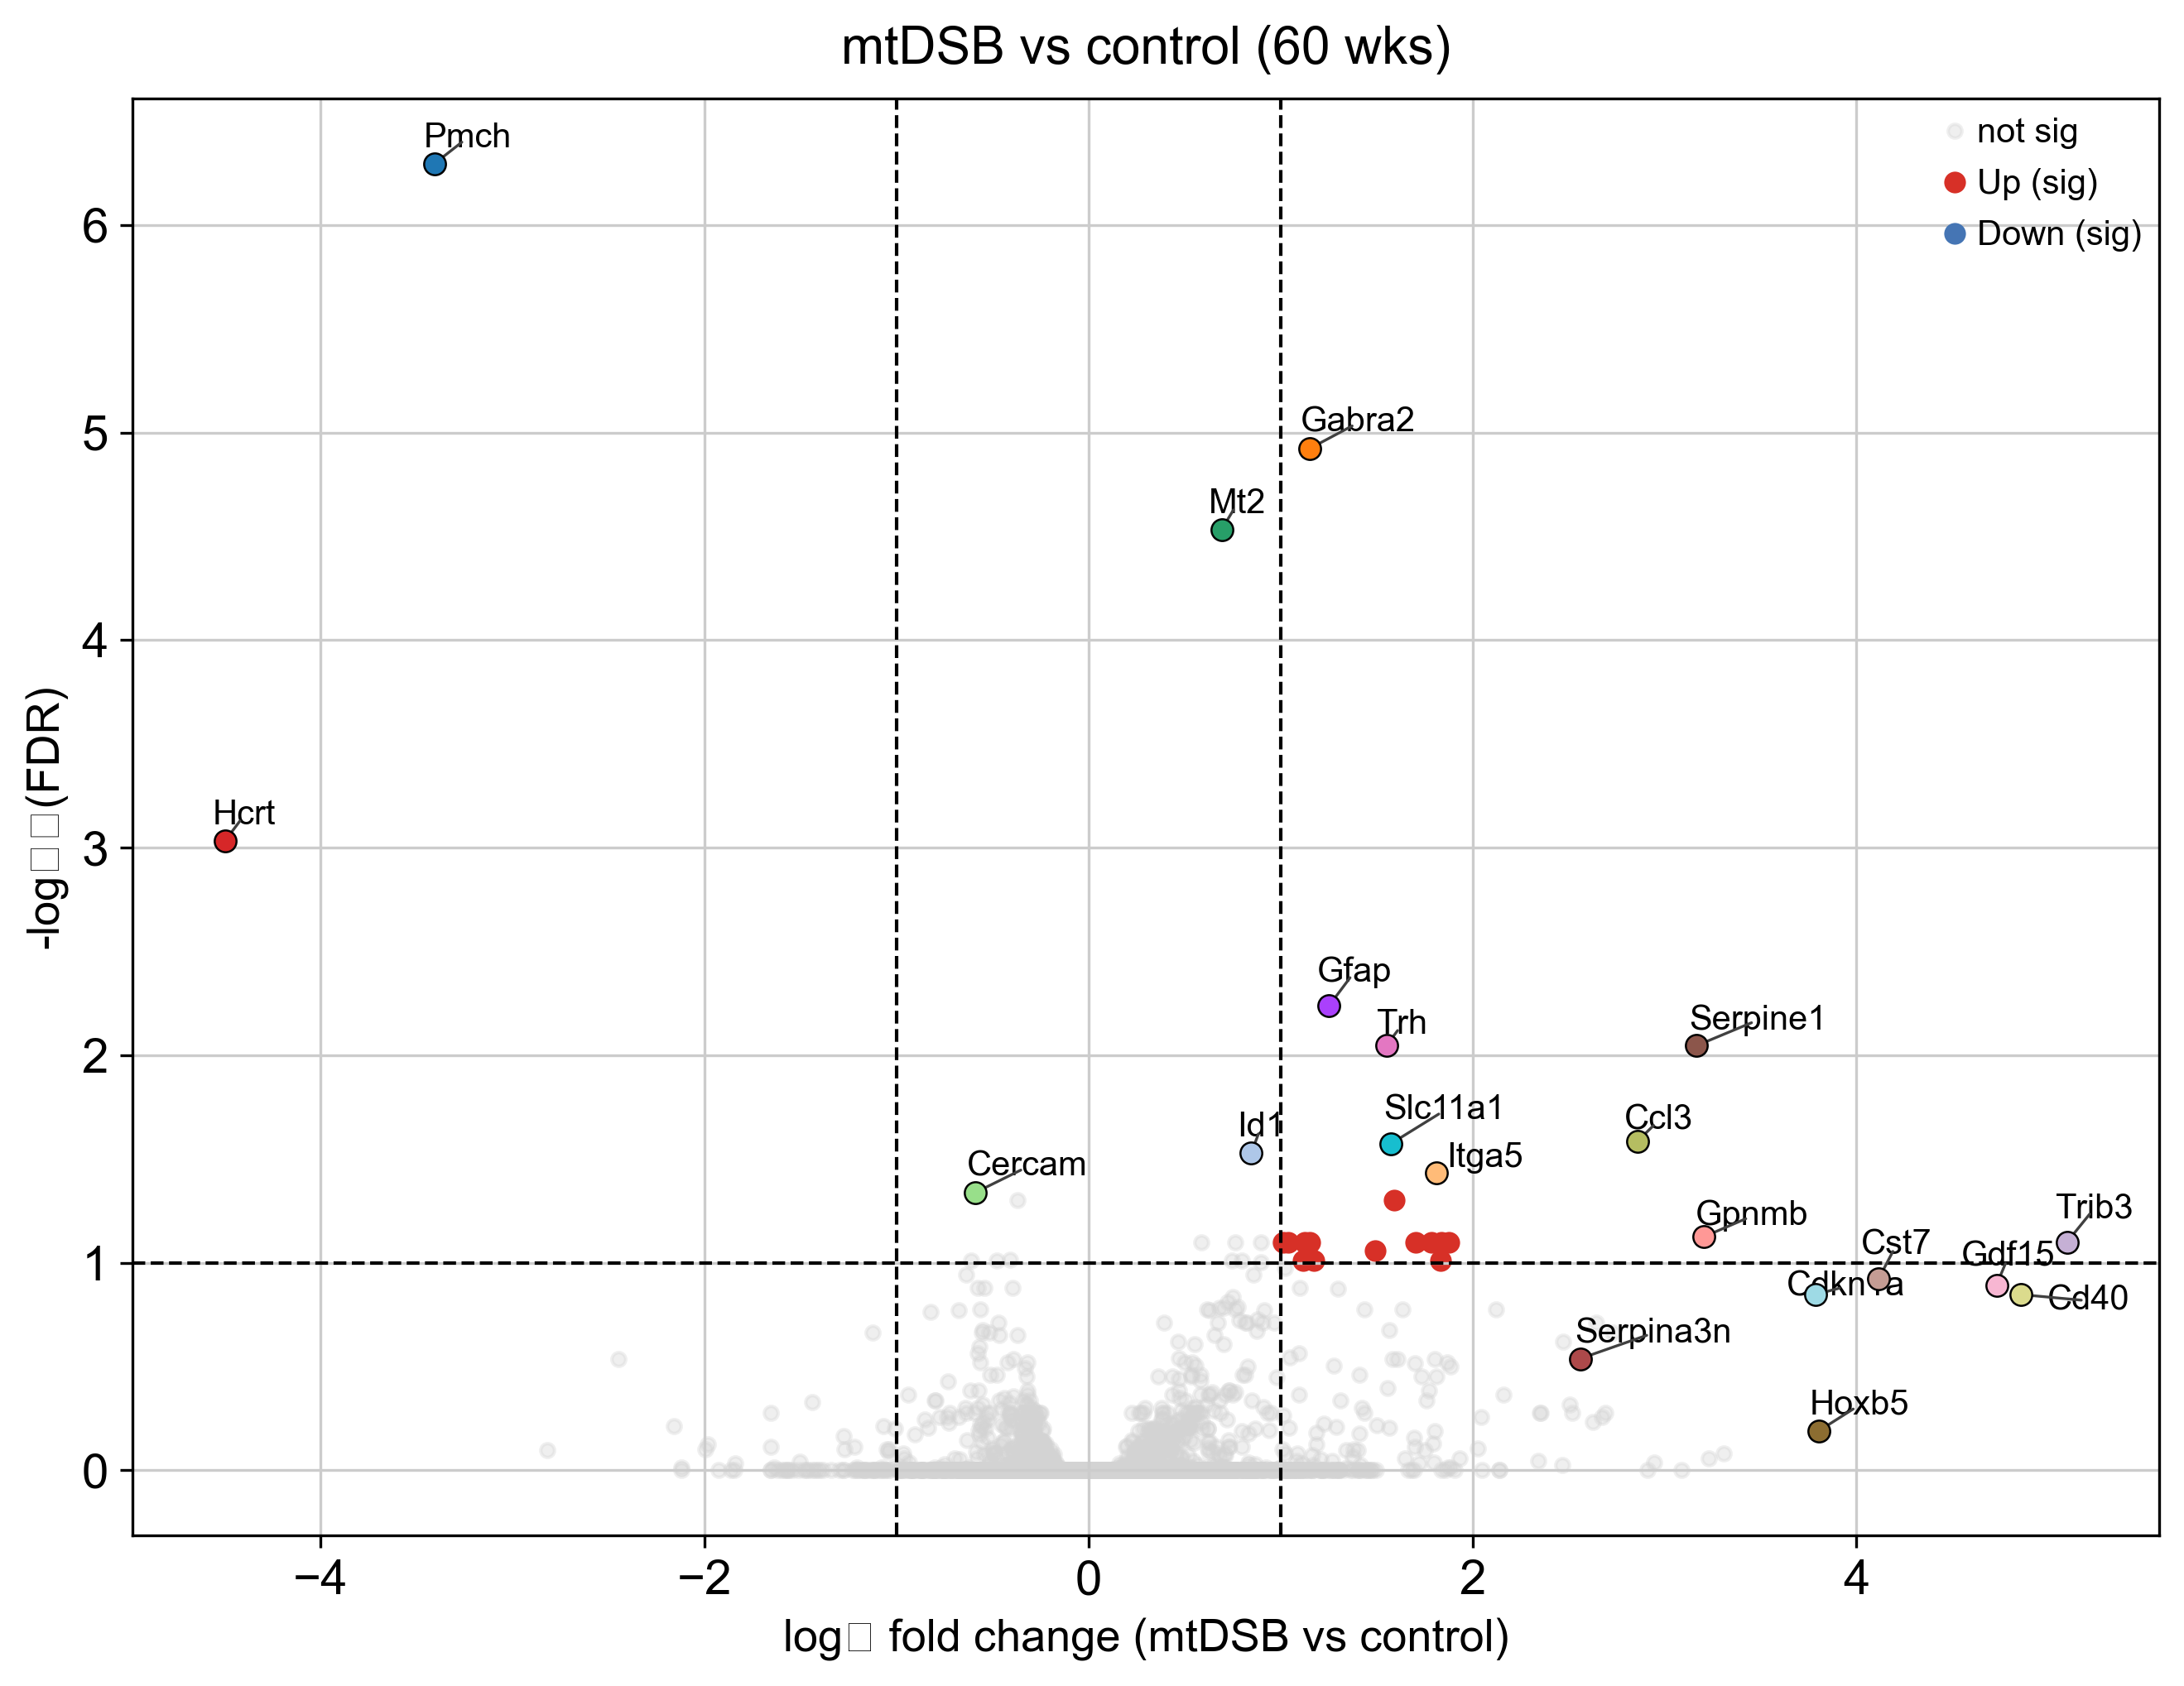

In [275]:
picked60 = volcano_clean(
    res60,
    title="mtDSB vs control (60 wks)",
    q=0.1, lfc_thr=1.0,
    label_top_fdr=12, label_top_abs_lfc=12, max_labels=20,
    highlight_genes=["Trib3", "Cst7", "Hspa5", "Gdf15", 'Serpina3n'],
    to_csv_path=None  # optional
)


=== Important genes (labeled on plot) ===
        log2FC   padj  -log10(FDR)  rank_fdr  rank_abs_lfc
gene                                                      
Fezf1    2.889  0.000         3.42       1.0          23.0
Mt1      1.129  0.000         3.32       2.0         244.0
Trh      2.008  0.010         2.00       3.0          65.0
Nkx6-2  -0.243  0.034         1.47       4.0        1545.0
Bglap2  -2.835  0.088         1.06       5.0          24.0
Trim36  -0.627  0.105         0.98       6.0         591.0
Otp      2.186  0.134         0.87       7.0          55.0
Rab10   -0.219  0.140         0.85       8.0        1673.0
Col1a1  -1.937  0.204         0.69       9.0          75.0
Col1a2  -1.433  0.204         0.69       9.0         152.0
Cst7     3.107  0.214         0.67      10.0          13.0
Bglap   -2.983  0.214         0.67      10.0          18.0
Hoxb3   -3.693  0.422         0.37      13.0           9.0
Hcrt     4.198  0.435         0.36      14.0           3.0
Hoxb5   -5.00

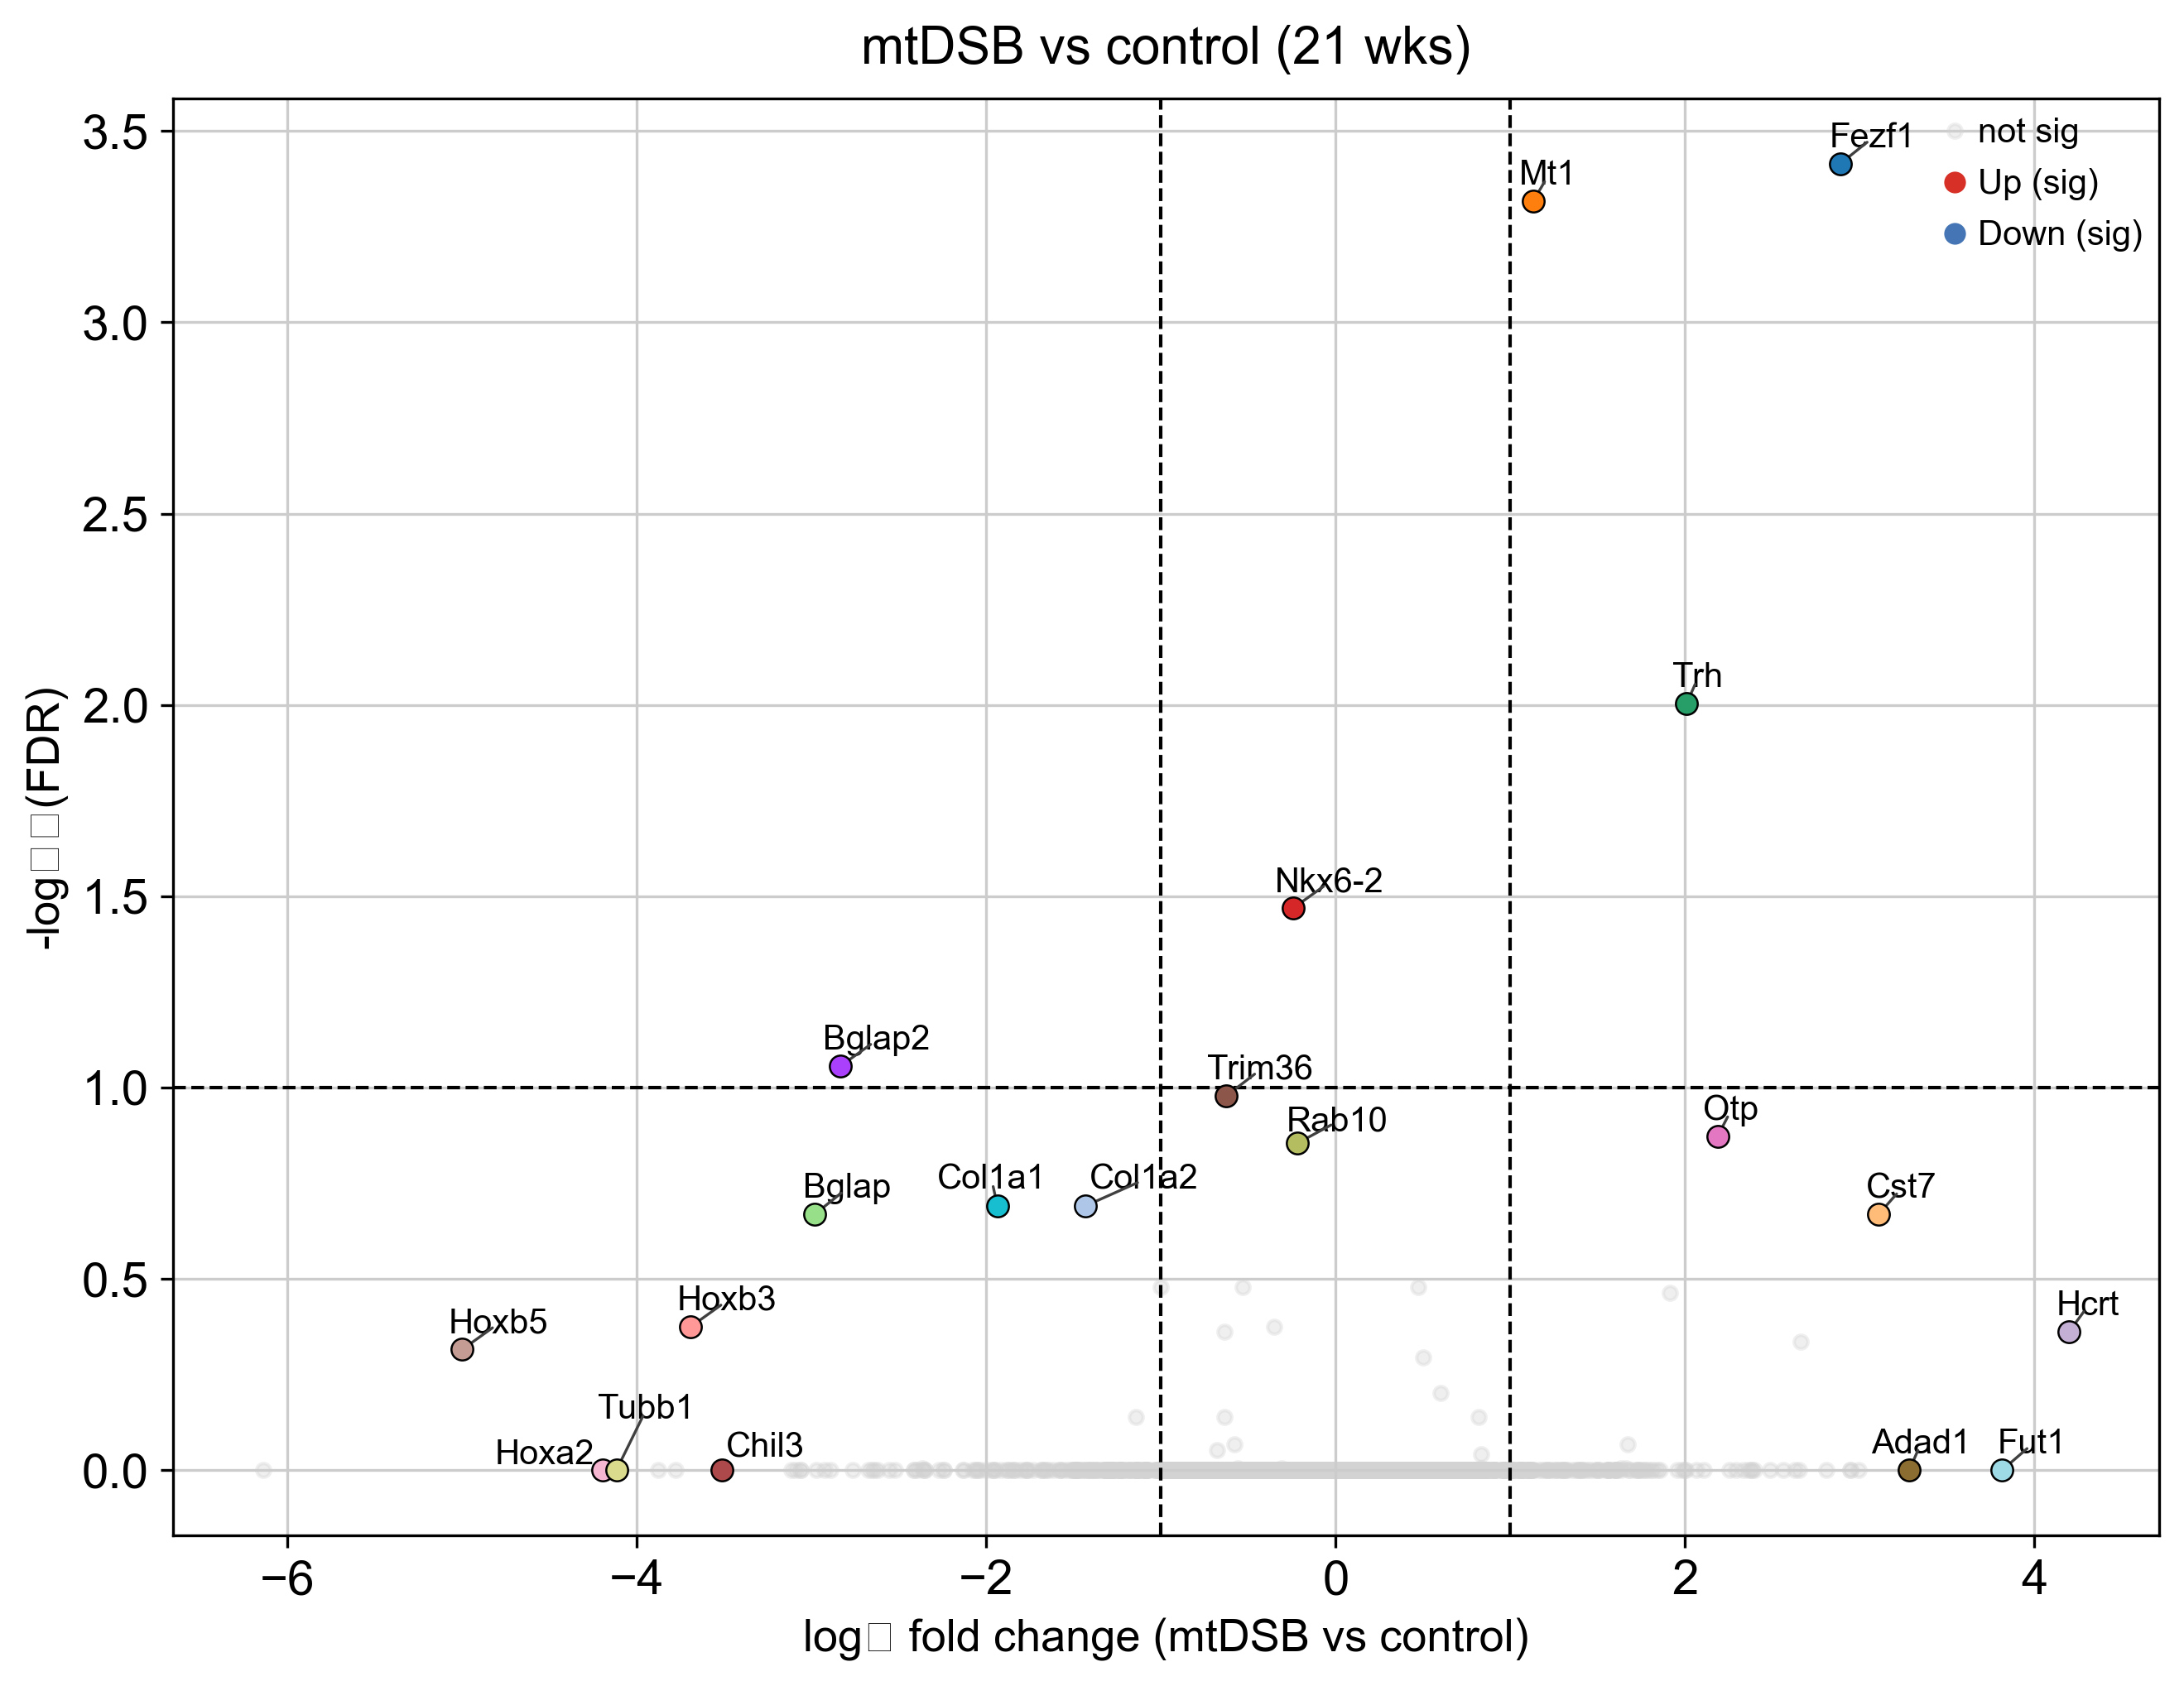

In [276]:
picked21 = volcano_clean(
    res21,
    title="mtDSB vs control (21 wks)",
    q=0.1, lfc_thr=1.0,
    label_top_fdr=12, label_top_abs_lfc=12, max_labels=20,
    highlight_genes=["Trib3", "Cst7", "Hspa5", "Gdf15", 'Serpina3n'],
    to_csv_path=None  # optional
)

In [277]:
import numpy as np
import pandas as pd

def pick_top_per_age(
    res21, res60,
    lfc_col="log2FC_mtDSB_vs_control",
                        padj_col="pvalue_mtDSB_vs_control",
    q=0.05,
    top_n_each=20,
    age_specific=False,        # keep genes sig at one age but not the other
    alpha_lfc=1.0,             # weight for |LFC|
    beta_p=0.5,                # weight for -log10(FDR); set to 0 for LFC-only
    max_labels=None
):
    """Pick top genes per age with LFC-prioritized scoring."""
    # Auto-detect columns if not supplied
    if lfc_col is None:
        lfc_col = "log2FoldChange" if "log2FoldChange" in res21.columns else \
                  [c for c in res21.columns if c.lower().startswith("log2fc")][0]
    if padj_col is None:
        padj_col = "padj" if "padj" in res21.columns else \
                  [c for c in res21.columns if c.lower().startswith("padj") or "fdr" in c.lower()][0]

    genes = res21.index.intersection(res60.index)
    A = res21.loc[genes, [lfc_col, padj_col]].rename(columns={lfc_col:"lfc21", padj_col:"padj21"})
    B = res60.loc[genes, [lfc_col, padj_col]].rename(columns={lfc_col:"lfc60", padj_col:"padj60"})
    df = A.join(B).replace([np.inf, -np.inf], np.nan).dropna()

    # Significance masks (FDR-based)
    sig21 = df["padj21"] < q
    sig60 = df["padj60"] < q

    # Scoring with LFC priority
    def score_part(lfc, padj):
        lfc_term = np.abs(lfc) ** alpha_lfc
        p_term = (-np.log10(np.clip(padj, 1e-300, 1.0))) ** beta_p
        return lfc_term * p_term

    s21 = score_part(df["lfc21"], df["padj21"])
    s60 = score_part(df["lfc60"], df["padj60"])

    # Rank within each age among significant genes (fallback to all if none)
    pool21 = df.loc[sig21] if sig21.any() else df
    pool60 = df.loc[sig60] if sig60.any() else df

    top21 = pool21.assign(score=s21.loc[pool21.index]).sort_values("score", ascending=False).head(top_n_each)
    top60 = pool60.assign(score=s60.loc[pool60.index]).sort_values("score", ascending=False).head(top_n_each)

    if age_specific:
        top21 = top21.loc[~sig60.reindex(top21.index, fill_value=False)]
        top60 = top60.loc[~sig21.reindex(top60.index, fill_value=False)]

    picks = list(pd.Index(top21.index).union(top60.index))
    if max_labels:
        smax = pd.DataFrame({"s21": s21, "s60": s60})
        smax["smax"] = smax[["s21","s60"]].max(axis=1)
        picks = smax.loc[picks].sort_values("smax", ascending=False).head(max_labels).index.tolist()

    return picks, top21.index.tolist(), top60.index.tolist()

In [278]:
def pick_top_per_age(
    res21, res60,
    lfc_col=None, padj_col=None,
    q=0.05, top_n_each=20, age_specific=False,
    alpha_lfc=1.0, beta_p=0.5,
    max_labels=None,
    force_top_abs_lfc_each=5,   # NEW: always include N largest |LFC| per age
    force_lfc_min=2.0           # only force-add if |LFC| >= this
):
    import numpy as np, pandas as pd
    if lfc_col is None:
        lfc_col = "log2FoldChange" if "log2FoldChange" in res21.columns else \
                  [c for c in res21.columns if c.lower().startswith("log2fc")][0]
    if padj_col is None:
        padj_col = "padj" if "padj" in res21.columns else \
                  [c for c in res21.columns if c.lower().startswith("padj") or "fdr" in c.lower()][0]

    genes = res21.index.intersection(res60.index)
    A = res21.loc[genes, [lfc_col, padj_col]].rename(columns={lfc_col:"lfc21", padj_col:"padj21"})
    B = res60.loc[genes, [lfc_col, padj_col]].rename(columns={lfc_col:"lfc60", padj_col:"padj60"})
    df = A.join(B).replace([np.inf, -np.inf], np.nan).dropna()

    sig21 = df["padj21"] < q
    sig60 = df["padj60"] < q

    def score_part(lfc, padj):
        l = np.abs(lfc) ** alpha_lfc
        p = (-np.log10(np.clip(padj, 1e-300, 1.0))) ** beta_p
        return l * p

    s21 = score_part(df["lfc21"], df["padj21"])
    s60 = score_part(df["lfc60"], df["padj60"])

    pool21 = df.loc[sig21] if sig21.any() else df
    pool60 = df.loc[sig60] if sig60.any() else df

    top21 = pool21.assign(score=s21.loc[pool21.index]).sort_values("score", ascending=False).head(top_n_each)
    top60 = pool60.assign(score=s60.loc[pool60.index]).sort_values("score", ascending=False).head(top_n_each)

    if age_specific:
        top21 = top21.loc[~sig60.reindex(top21.index, fill_value=False)]
        top60 = top60.loc[~sig21.reindex(top60.index, fill_value=False)]

    # ---- FORCE-ADD large |LFC| even if padj >= q ----
    if force_top_abs_lfc_each and force_top_abs_lfc_each > 0:
        force21 = (df.loc[~sig21 & (df["lfc21"].abs() >= force_lfc_min), "lfc21"]
                   .abs().sort_values(ascending=False).head(force_top_abs_lfc_each)).index
        force60 = (df.loc[~sig60 & (df["lfc60"].abs() >= force_lfc_min), "lfc60"]
                   .abs().sort_values(ascending=False).head(force_top_abs_lfc_each)).index
    else:
        force21 = force60 = pd.Index([])

    picks = list(pd.Index(top21.index).union(top60.index).union(force21).union(force60))

    if max_labels:
        smax = pd.DataFrame({"s21": s21, "s60": s60})
        smax["smax"] = smax[["s21","s60"]].max(axis=1)
        picks = smax.loc[picks].sort_values("smax", ascending=False).head(max_labels).index.tolist()

    return picks, top21.index.tolist(), top60.index.tolist()

In [279]:
import matplotlib.pyplot as plt
import numpy as np

def compare_lfc_scatter_colored_labels(
    res_early,
    res_late,
    lfc_col="log2FC_mtDSB_vs_control",
                        padj_col="pvalue_mtDSB_vs_control",
    title="Oligodendrocytes: 21w vs 60w",
    highlight_genes=None,
    q=0.05,
    figsize=(8,8),
    fontsize=12,
    top_n_delta=15     # auto-label top genes by |ΔLFC|
):
    from adjustText import adjust_text

    # --- Merge results ---
    genes = res_early.index.intersection(res_late.index)
    df = (
        res_early.loc[genes, [lfc_col, padj_col]]
        .rename(columns={lfc_col:"lfc_21w", padj_col:"padj_21w"})
        .join(res_late.loc[genes, [lfc_col, padj_col]]
              .rename(columns={lfc_col:"lfc_60w", padj_col:"padj_60w"}))
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["lfc_21w","lfc_60w"])
    )

    # ΔLFC and significance
    df["deltaLFC"] = df["lfc_60w"] - df["lfc_21w"]
    df["sig"] = (df["padj_21w"] < q) | (df["padj_60w"] < q)

    # --- Base scatter ---
    plt.figure(figsize=figsize, dpi=150)
    sc = plt.scatter(
        df["lfc_21w"],
        df["lfc_60w"],
        c=df["deltaLFC"],
        cmap="coolwarm",
        s=20,
        alpha=0.7,
        edgecolor="none"
    )

    # --- Highlight significant points with black edge ---
    plt.scatter(
        df.loc[df["sig"], "lfc_21w"],
        df.loc[df["sig"], "lfc_60w"],
        c=df.loc[df["sig"], "deltaLFC"],
        cmap="coolwarm",
        s=45,
        edgecolor="black",
        linewidth=0.3,
        alpha=0.9,
        zorder=3
    )

    # --- Axes and reference lines ---
    lim = np.nanmax(np.abs(df[["lfc_21w","lfc_60w"]].values)) * 1.05
    plt.axhline(0, color="k", ls="--", lw=1)
    plt.axvline(0, color="k", ls="--", lw=1)
    plt.plot([-lim, lim], [-lim, lim], color="k", ls=":", lw=1)
    plt.xlim(-lim, lim)
    plt.ylim(-lim, lim)
    plt.xlabel("log₂FC (21 weeks)", fontsize=fontsize)
    plt.ylabel("log₂FC (60 weeks)", fontsize=fontsize)
    plt.title(title, fontsize=fontsize+2)

    # --- Choose which genes to label ---
    picks = set()
    if highlight_genes:
        picks.update(df.index.intersection(highlight_genes))
    # add top ΔLFC genes if not already included
    picks.update(df["deltaLFC"].abs().sort_values(ascending=False).head(top_n_delta).index)

    # --- Add labels with arrows and repel them ---
    texts = []
    for g in picks:
        if g not in df.index:
            continue
        x, y = df.at[g, "lfc_21w"], df.at[g, "lfc_60w"]
        t = plt.text(
            x, y, g,
            fontsize=fontsize-3,
            ha="center",
            va="center",
            color="black"
        )
        texts.append(t)

    adjust_text(
        texts,
        expand_points=(1.2, 1.3),
        expand_text=(1.2, 1.3),
        arrowprops=dict(arrowstyle="-", lw=0.7, color="0.4", alpha=0.8),
        only_move={'points':'y', 'text':'xy'}
    )

    # --- Add colorbar ---
    cb = plt.colorbar(sc)
    cb.set_label("Δ log₂FC (60w − 21w)", fontsize=fontsize-2)

    plt.tight_layout()
    plt.show()

    return df

## Compare LFC across age and cell type

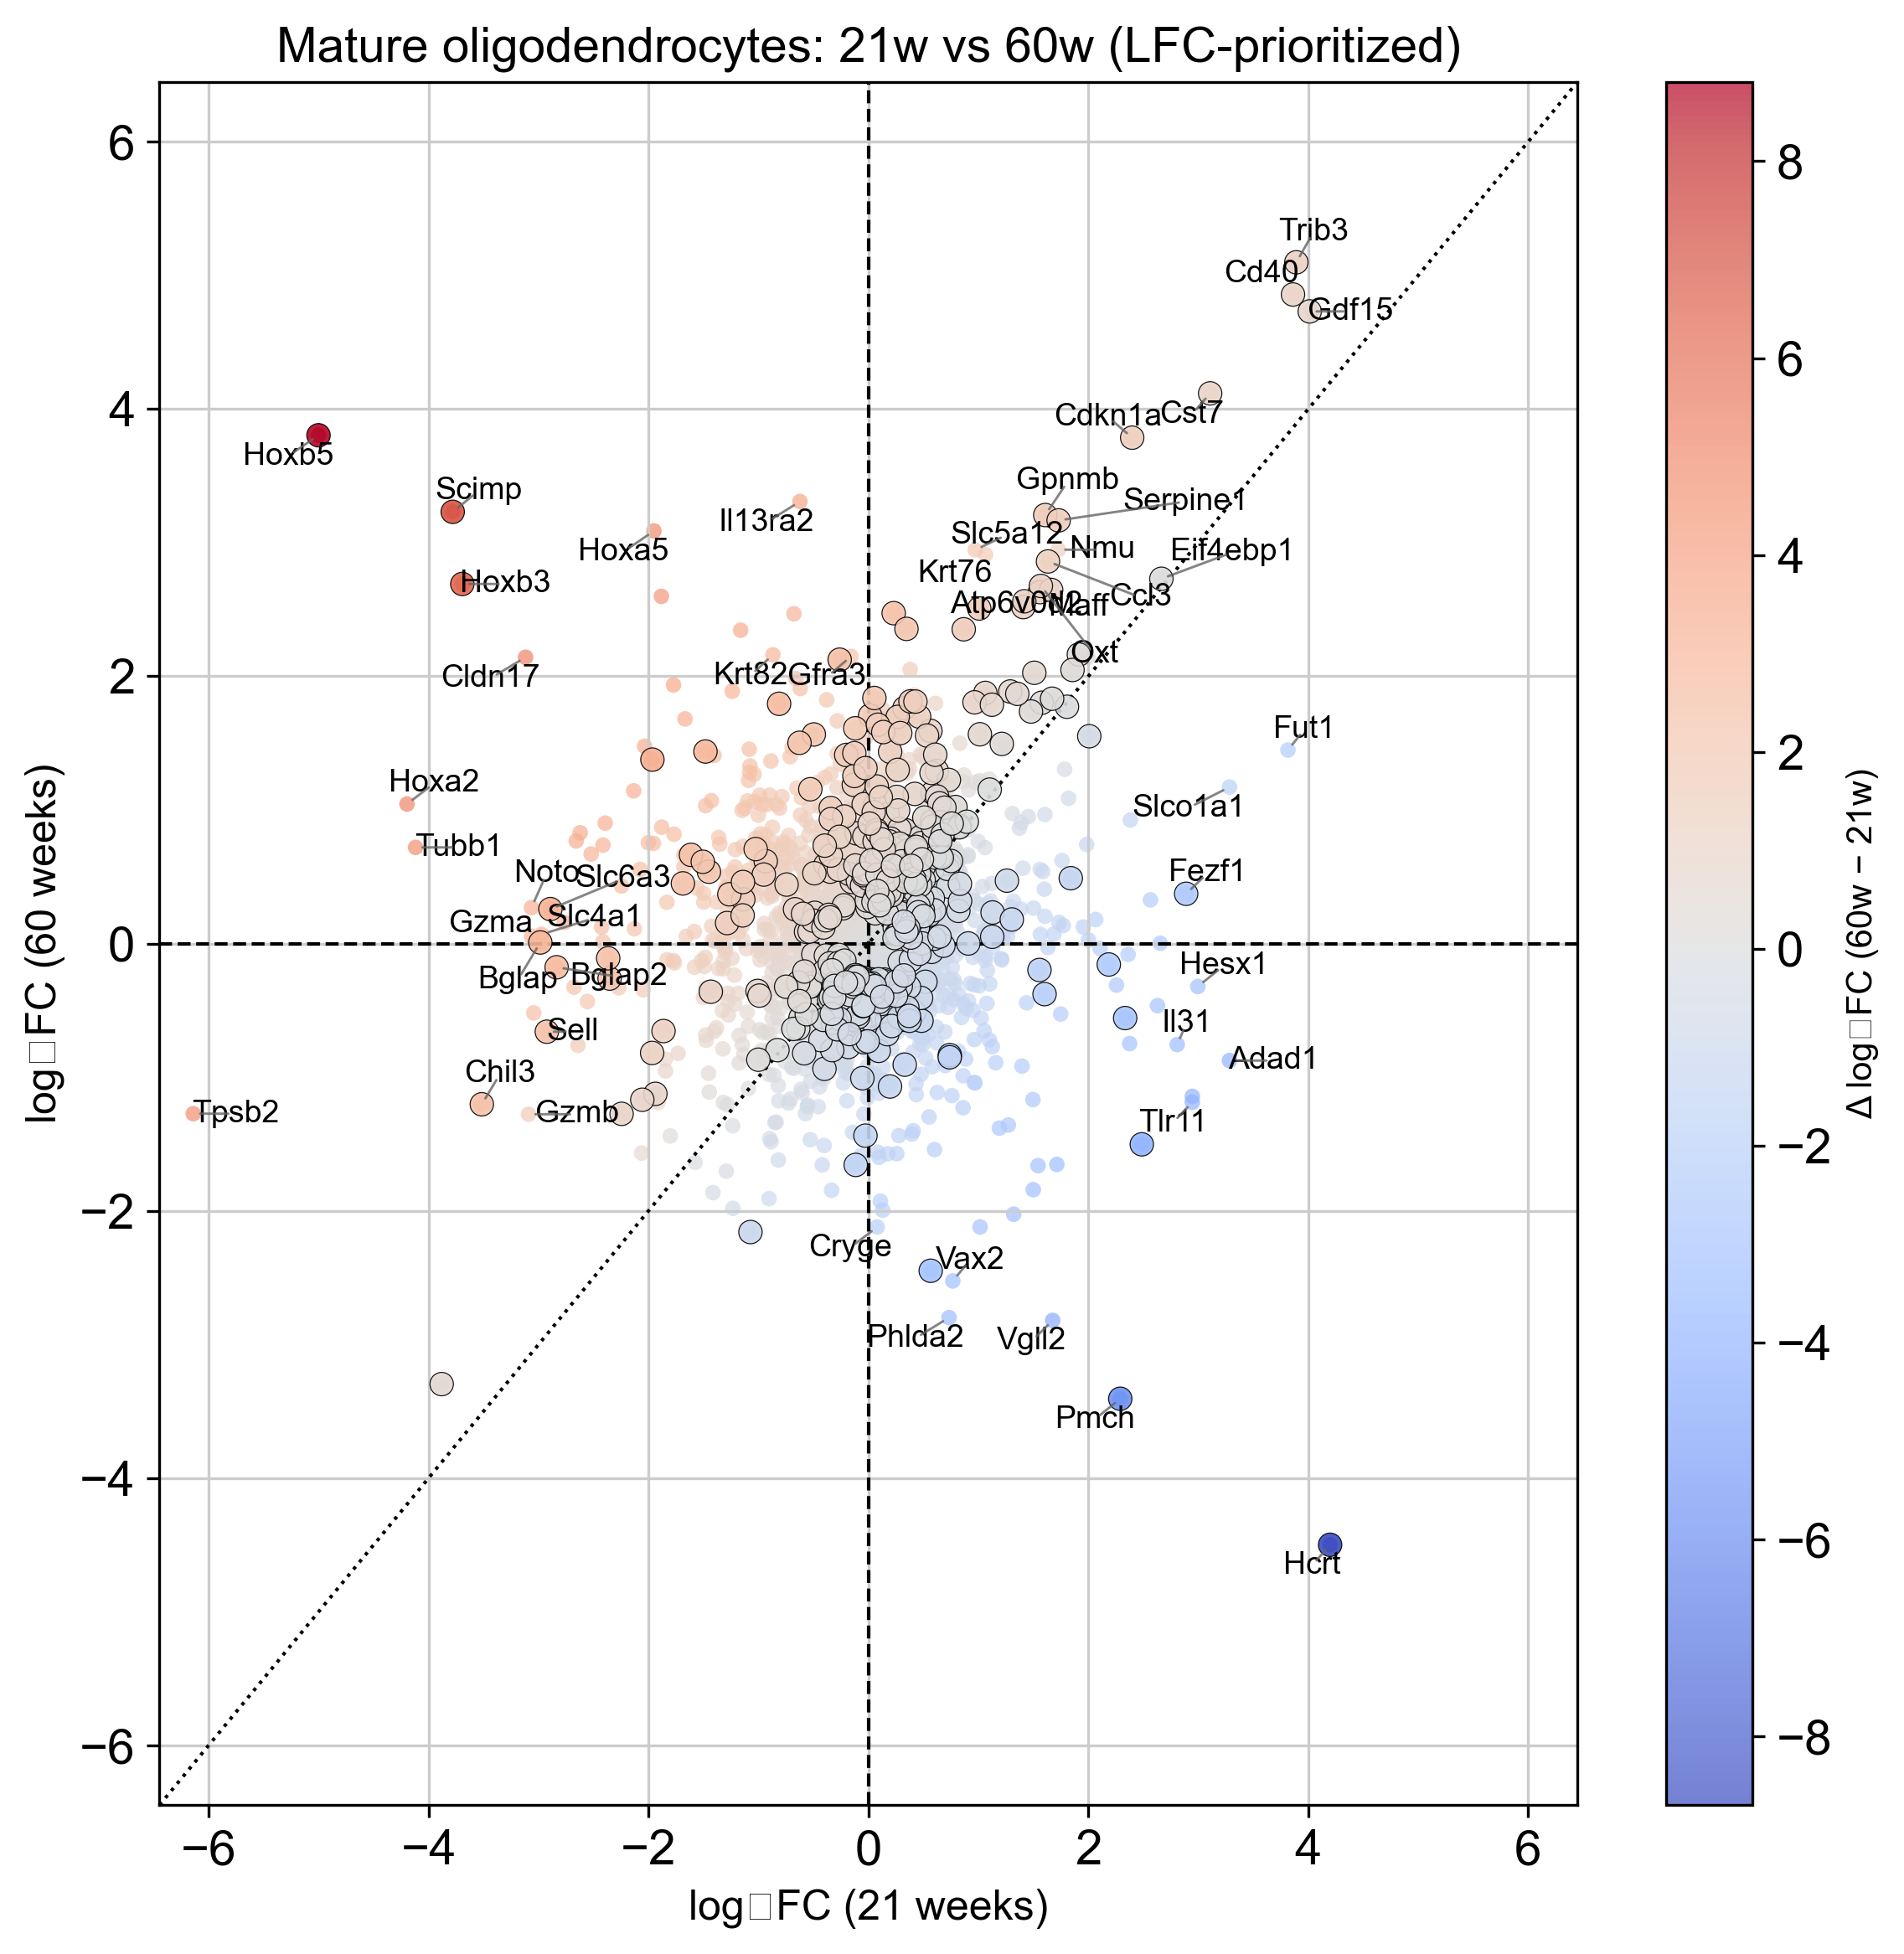

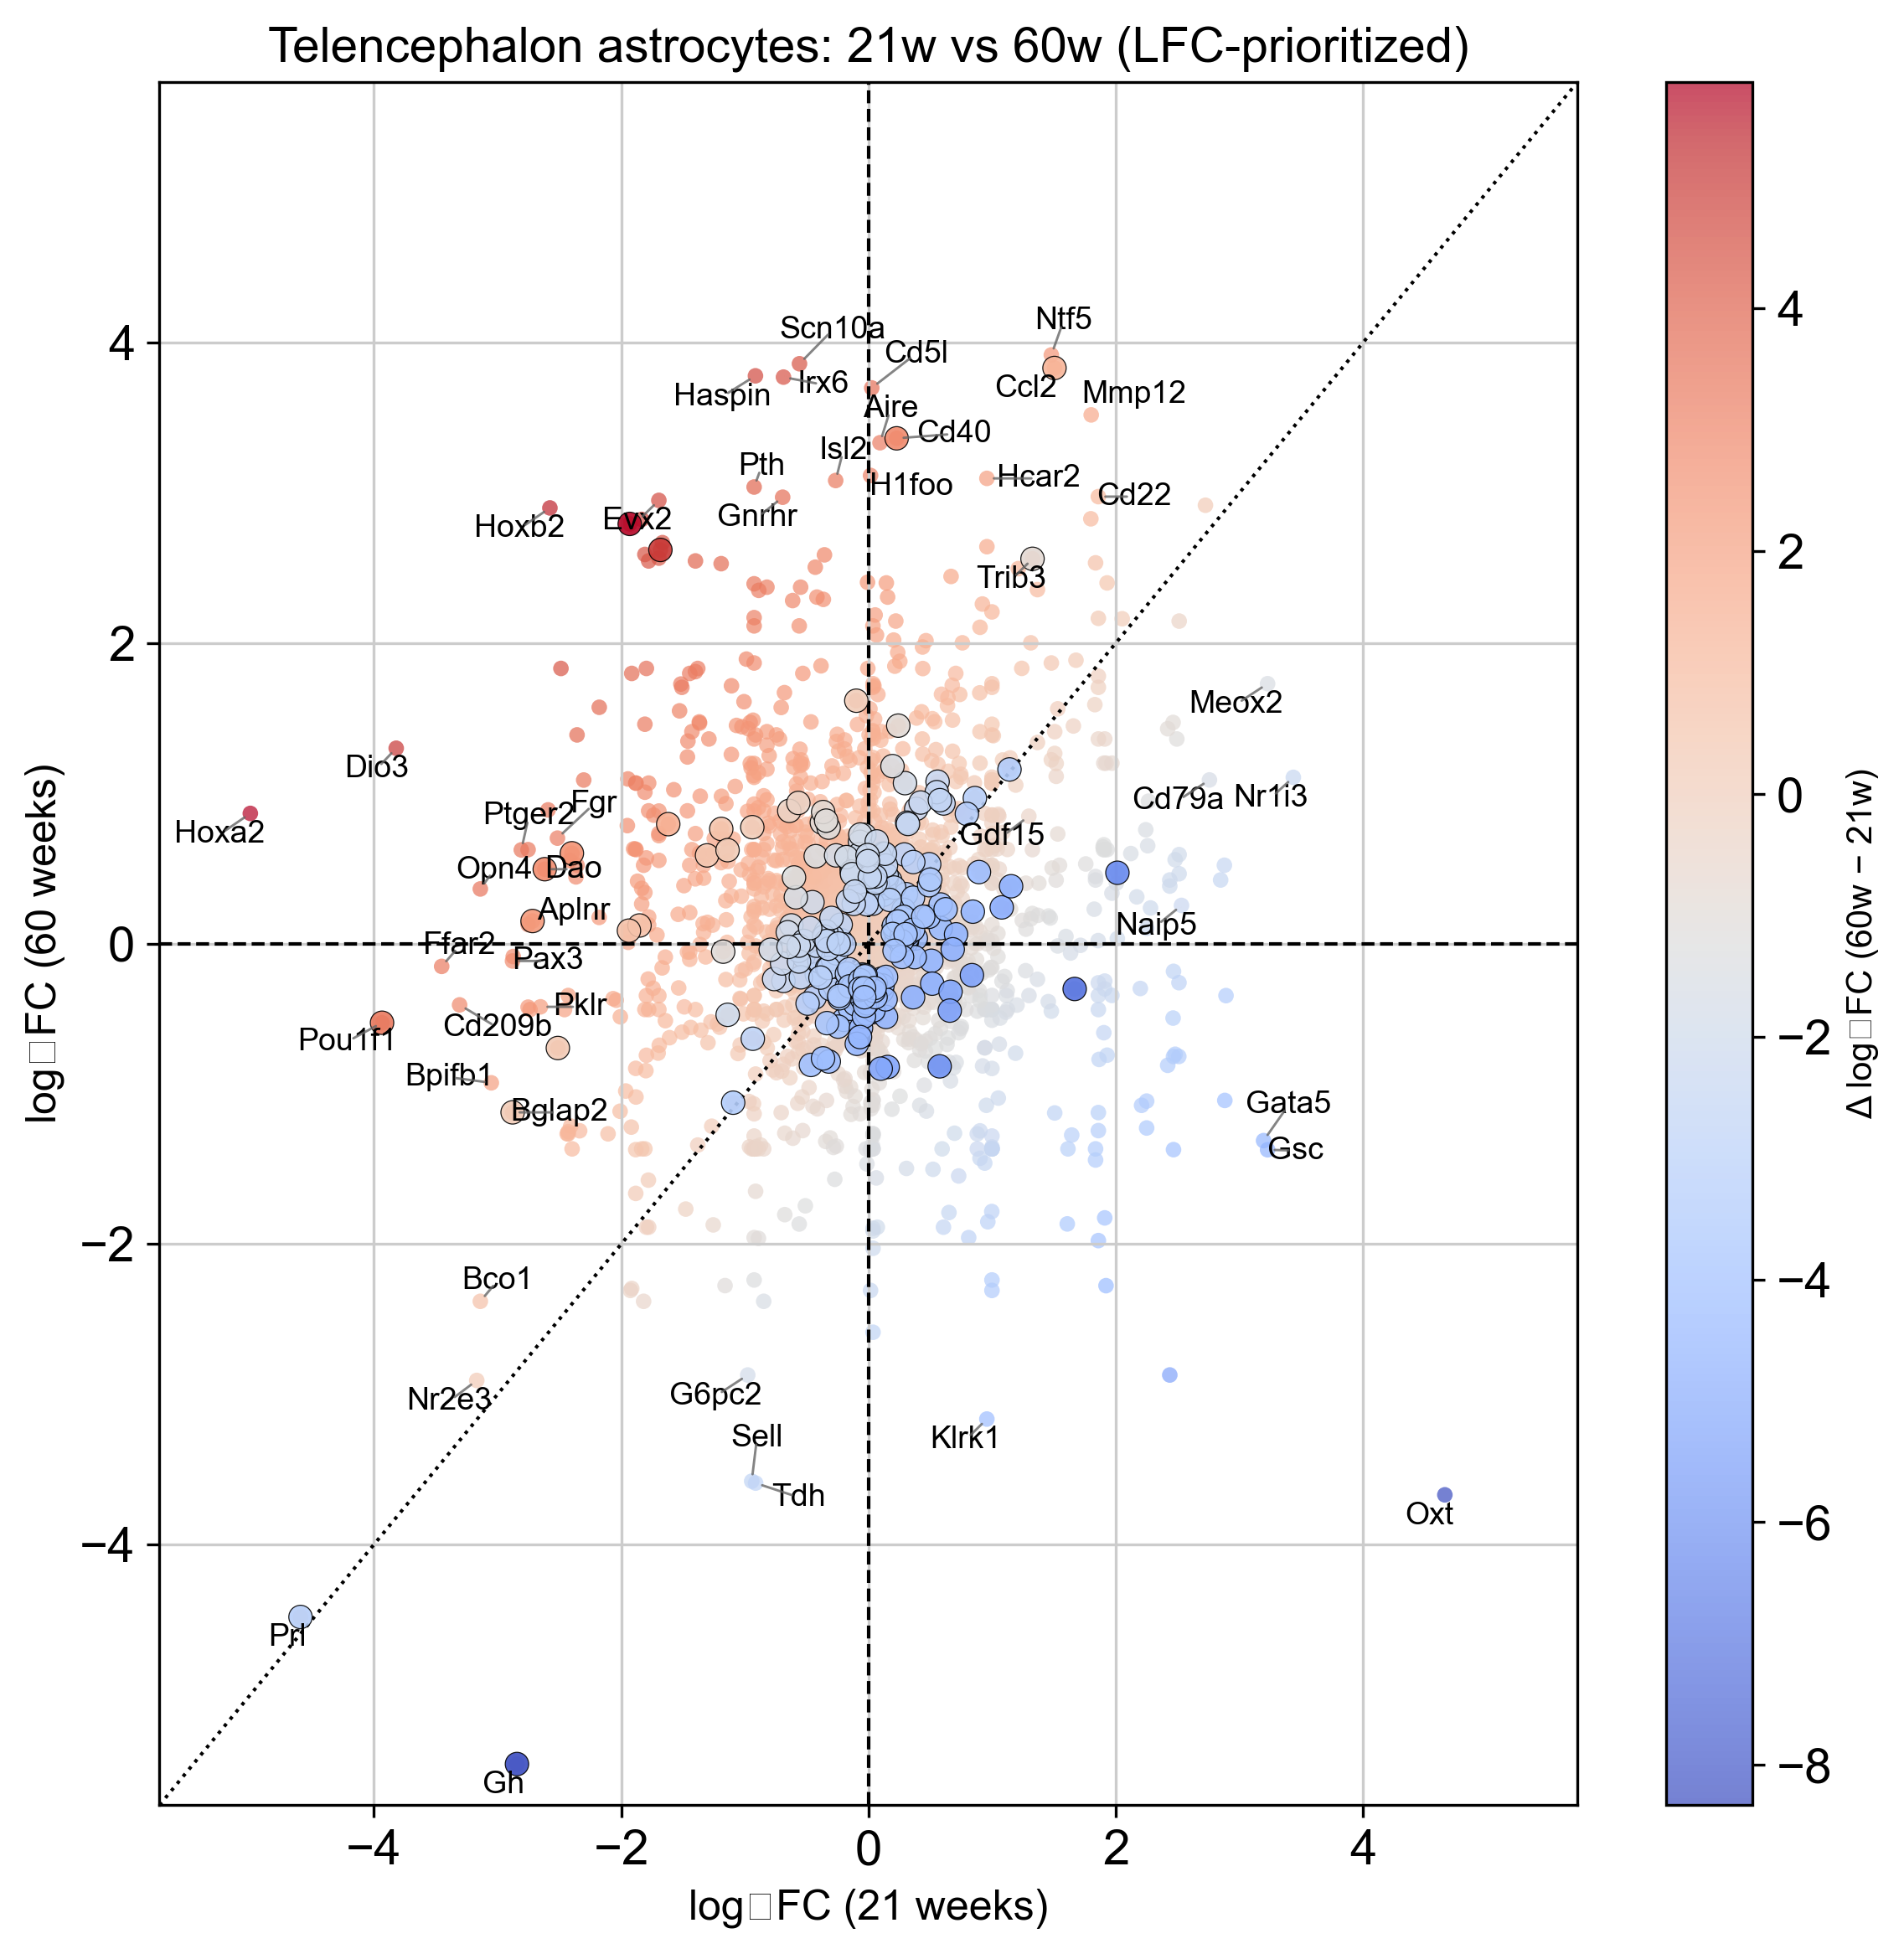

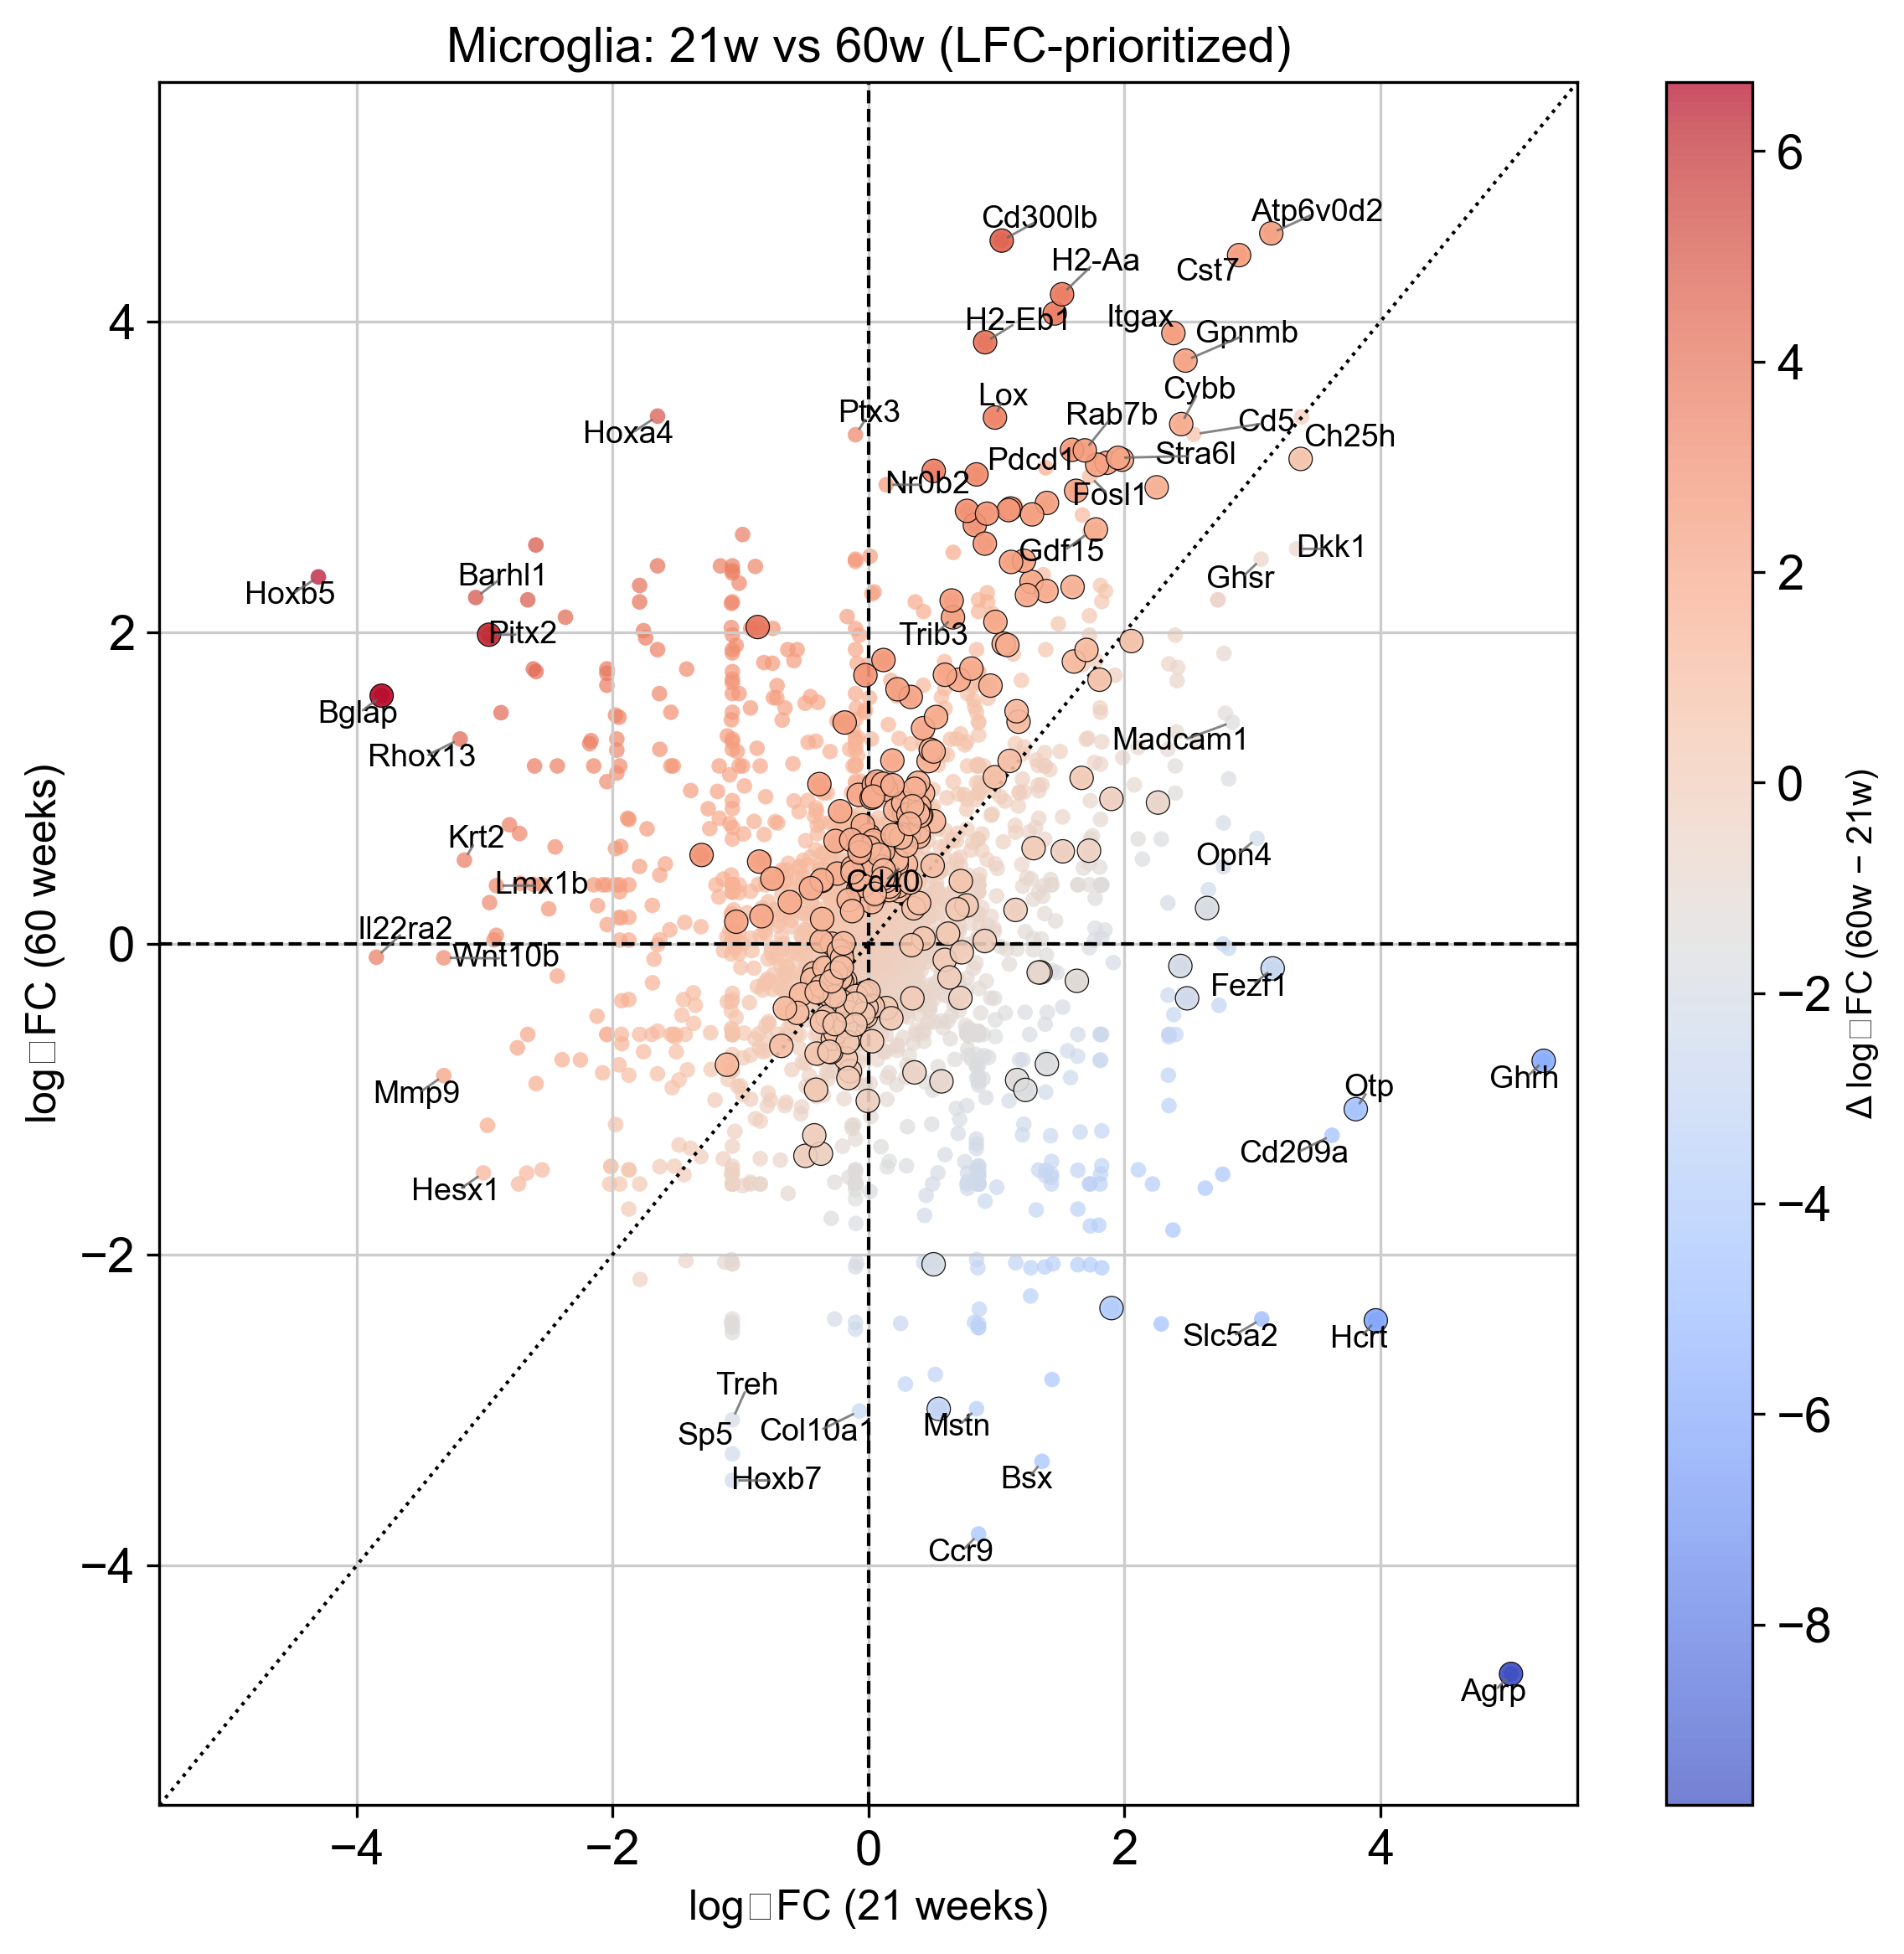

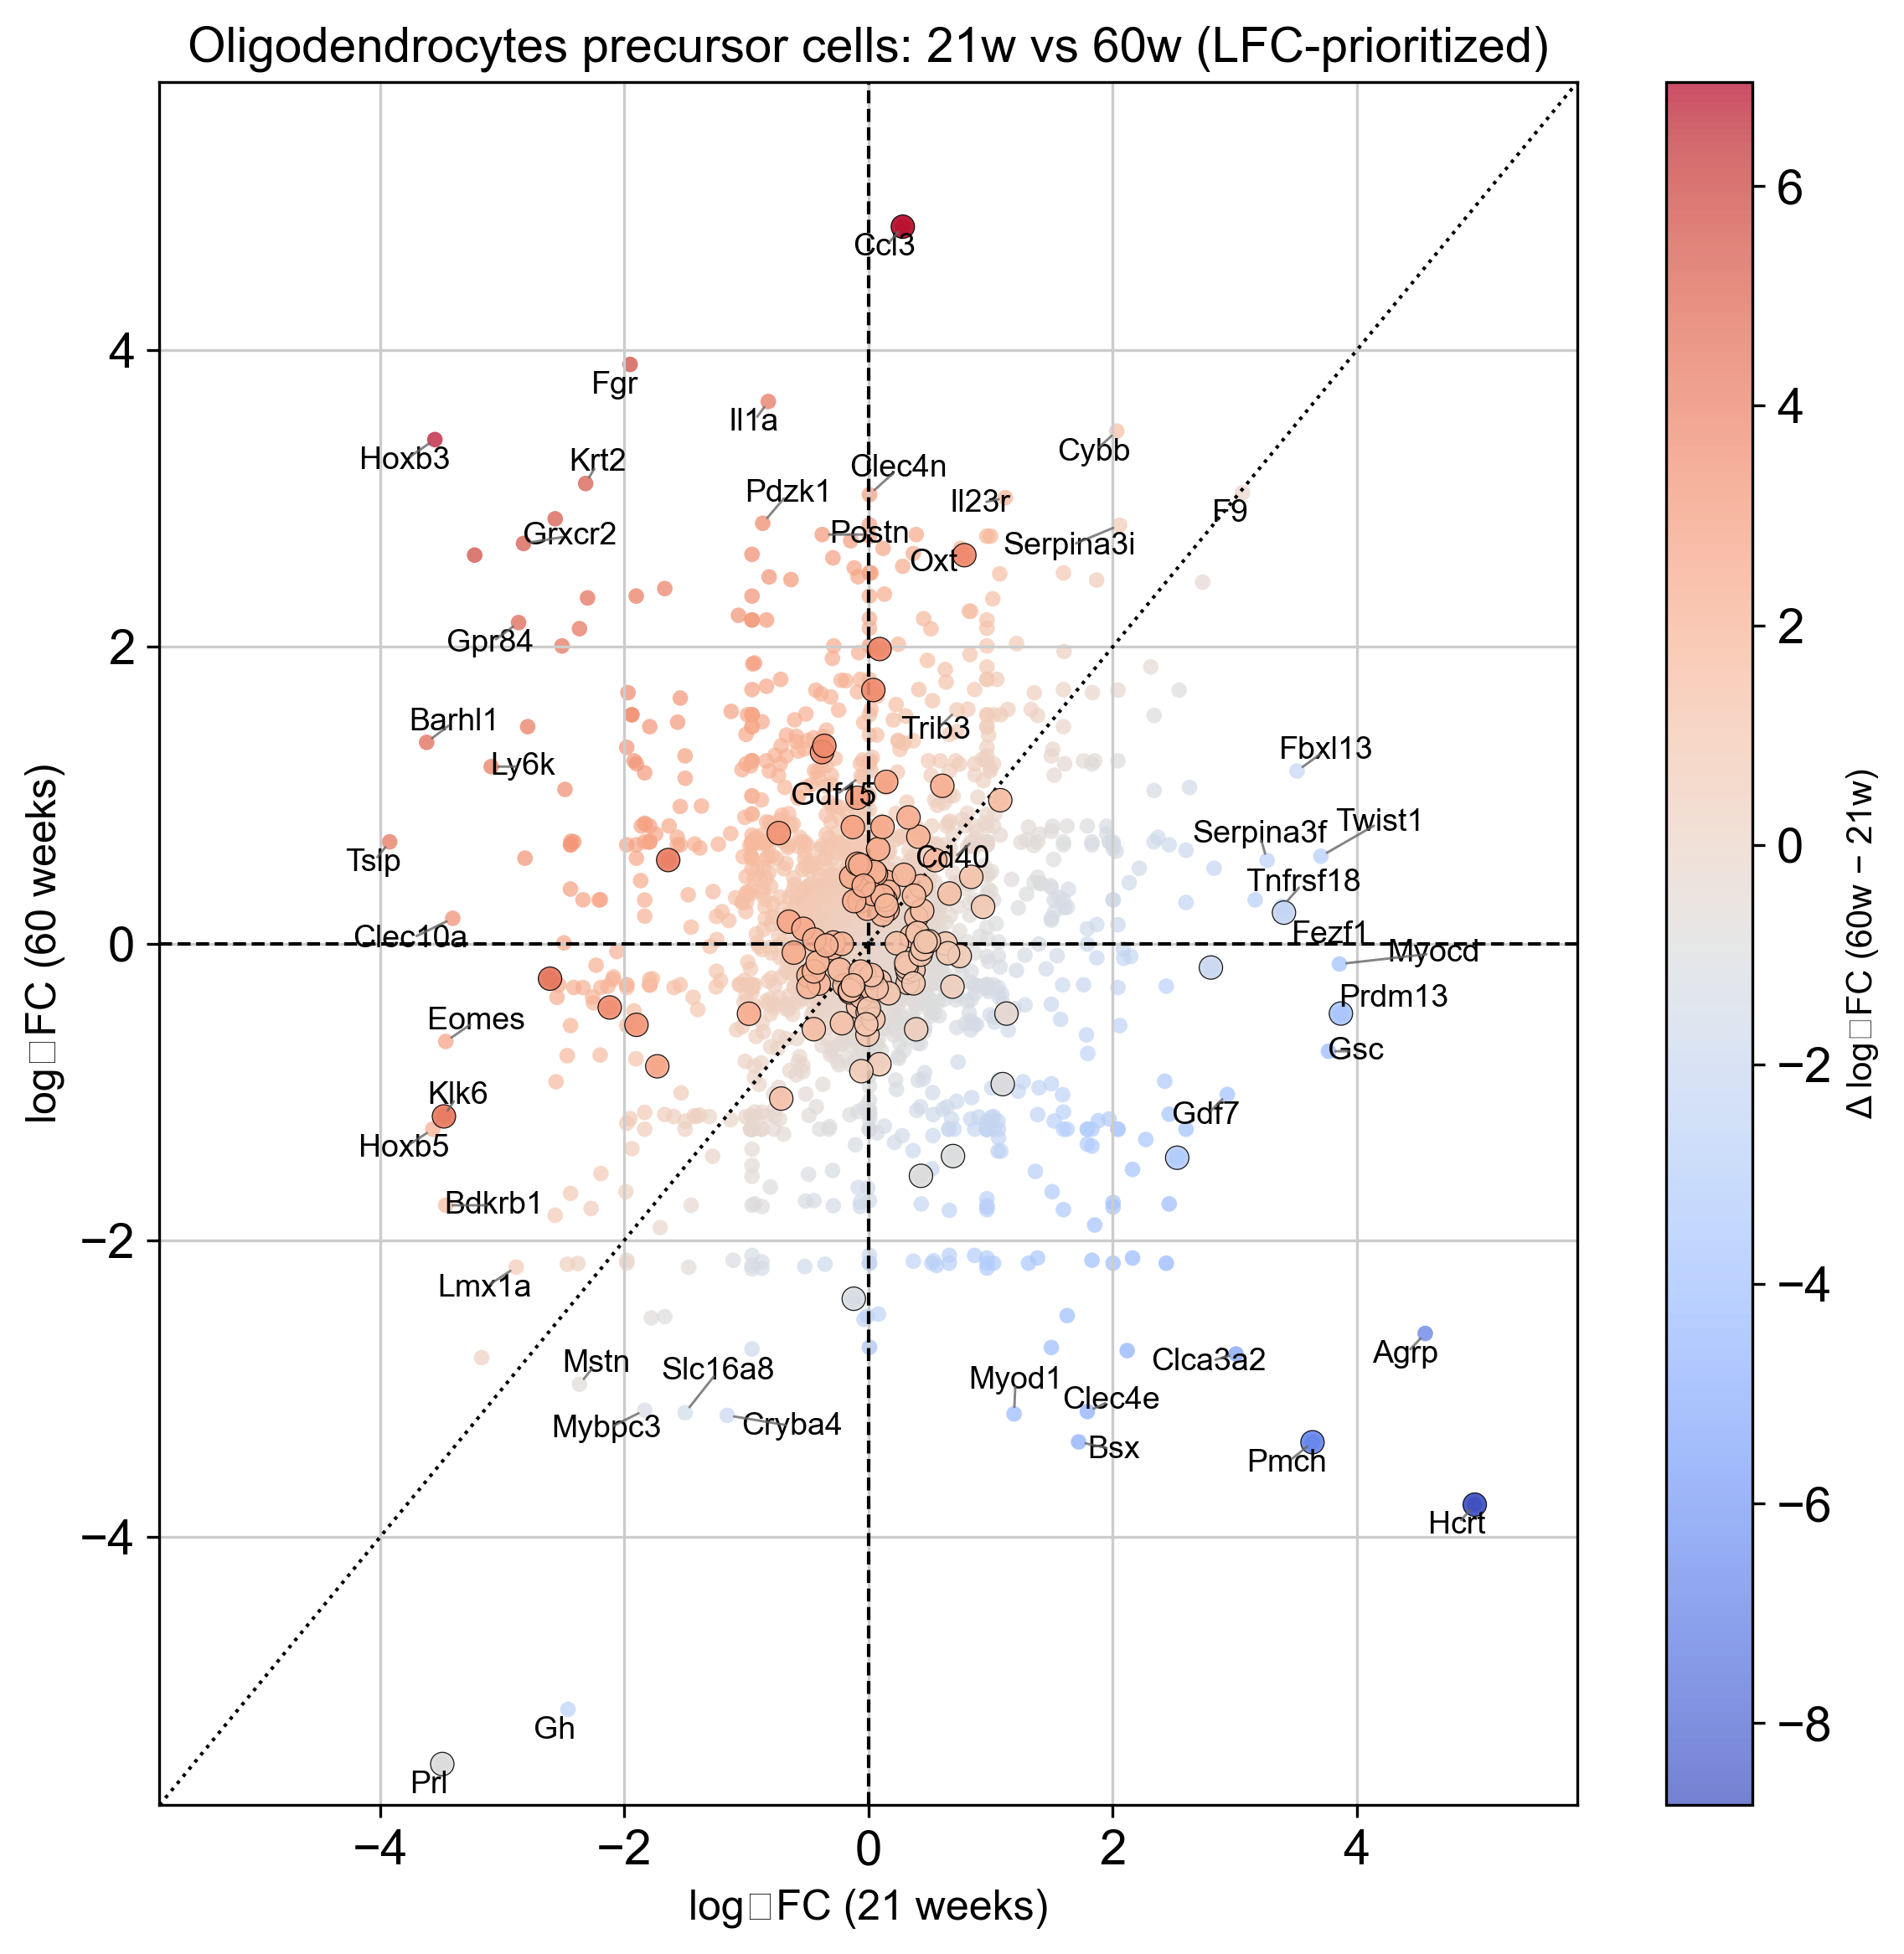

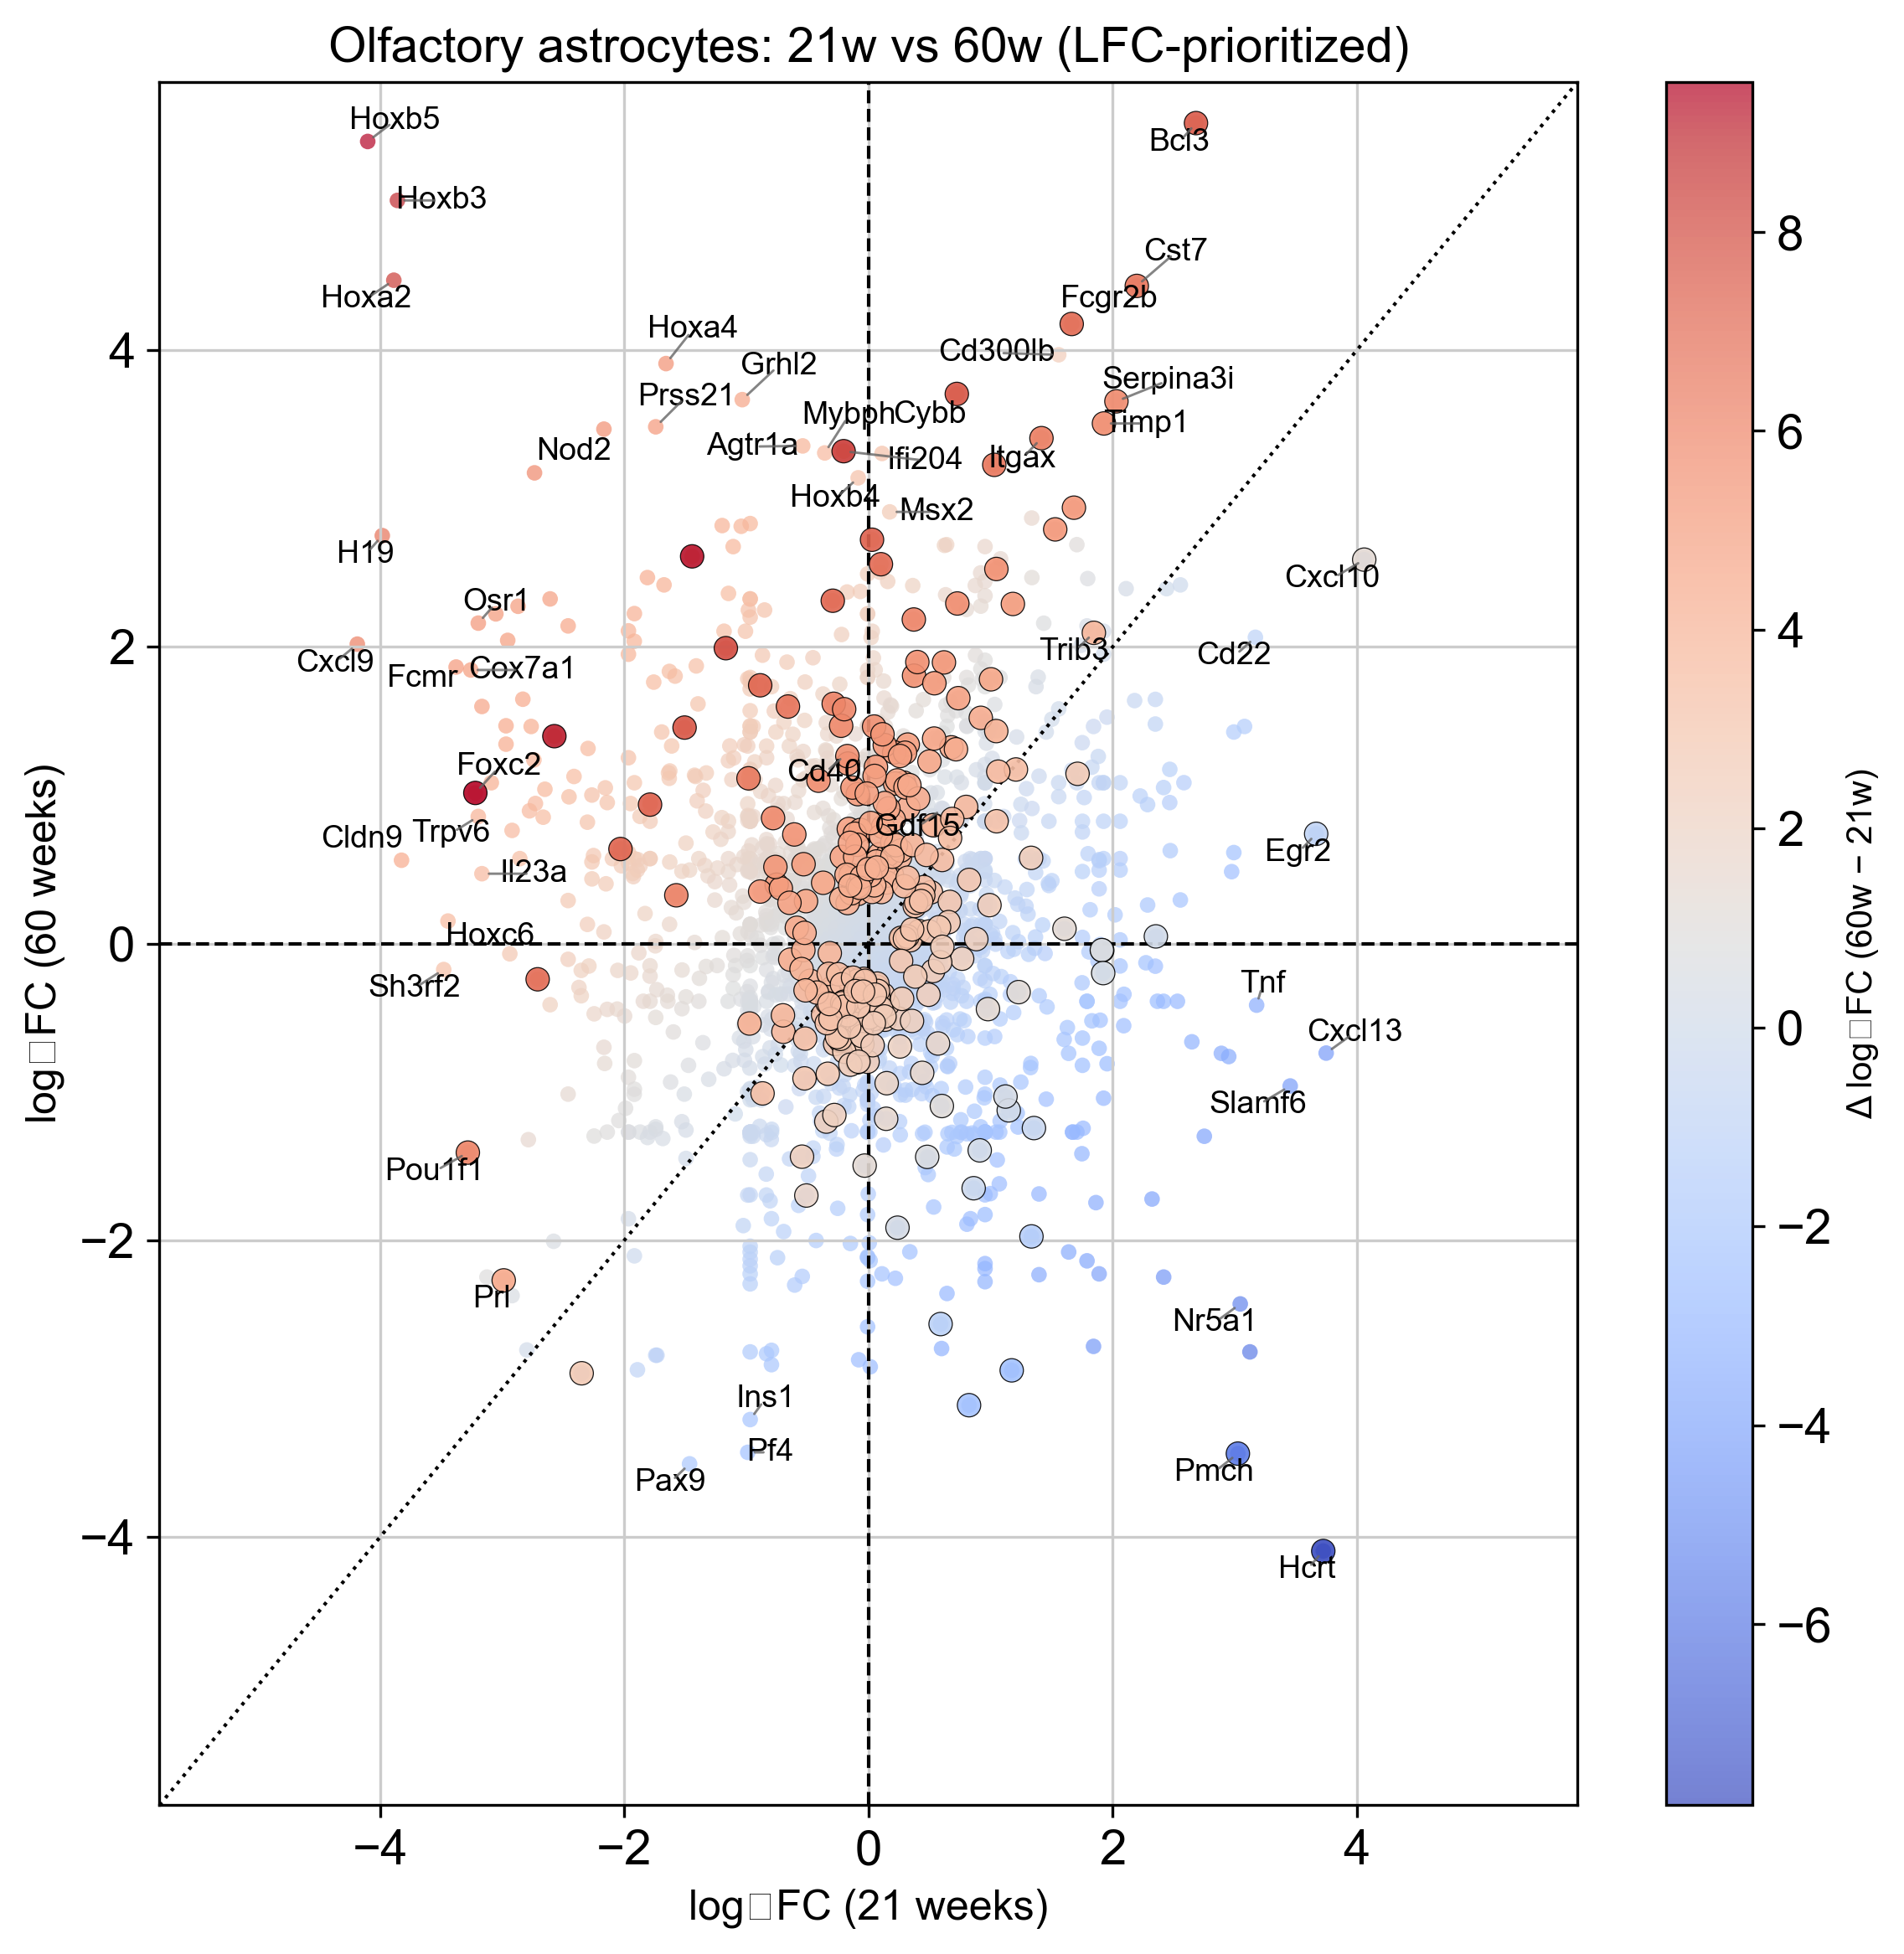

In [292]:
for cell in results.keys():
    res21 = results[cell]["simple_effects"]["21"]
    res60 = results[cell]["simple_effects"]["60"]
    
    # Prioritize big fold-changes; modest weight on FDR
    picks, top21, top60 = pick_top_per_age(
        res21, res60,
        q=0.25, top_n_each=20,
        lfc_col='log2FC_mtDSB_vs_control',
        padj_col='pvalue_mtDSB_vs_control',
        alpha_lfc=1.0,   # stronger effect-size priority
        beta_p=0.0,     # lighter FDR weight; set 0 for pure LFC-based
        force_lfc_min=0.0,          # only if |LFC| ≥ 2.5
        max_labels=100
    )
    
    df_comp = compare_lfc_scatter_colored_labels(
        res_early=res21,
        res_late=res60,
        highlight_genes=picks+['Trib3','Cd40','Gdf15'],
        title=cell + ": 21w vs 60w (LFC-prioritized)",
        top_n_delta=0  # labels come from 'picks' instead of ΔLFC auto-labels
    )

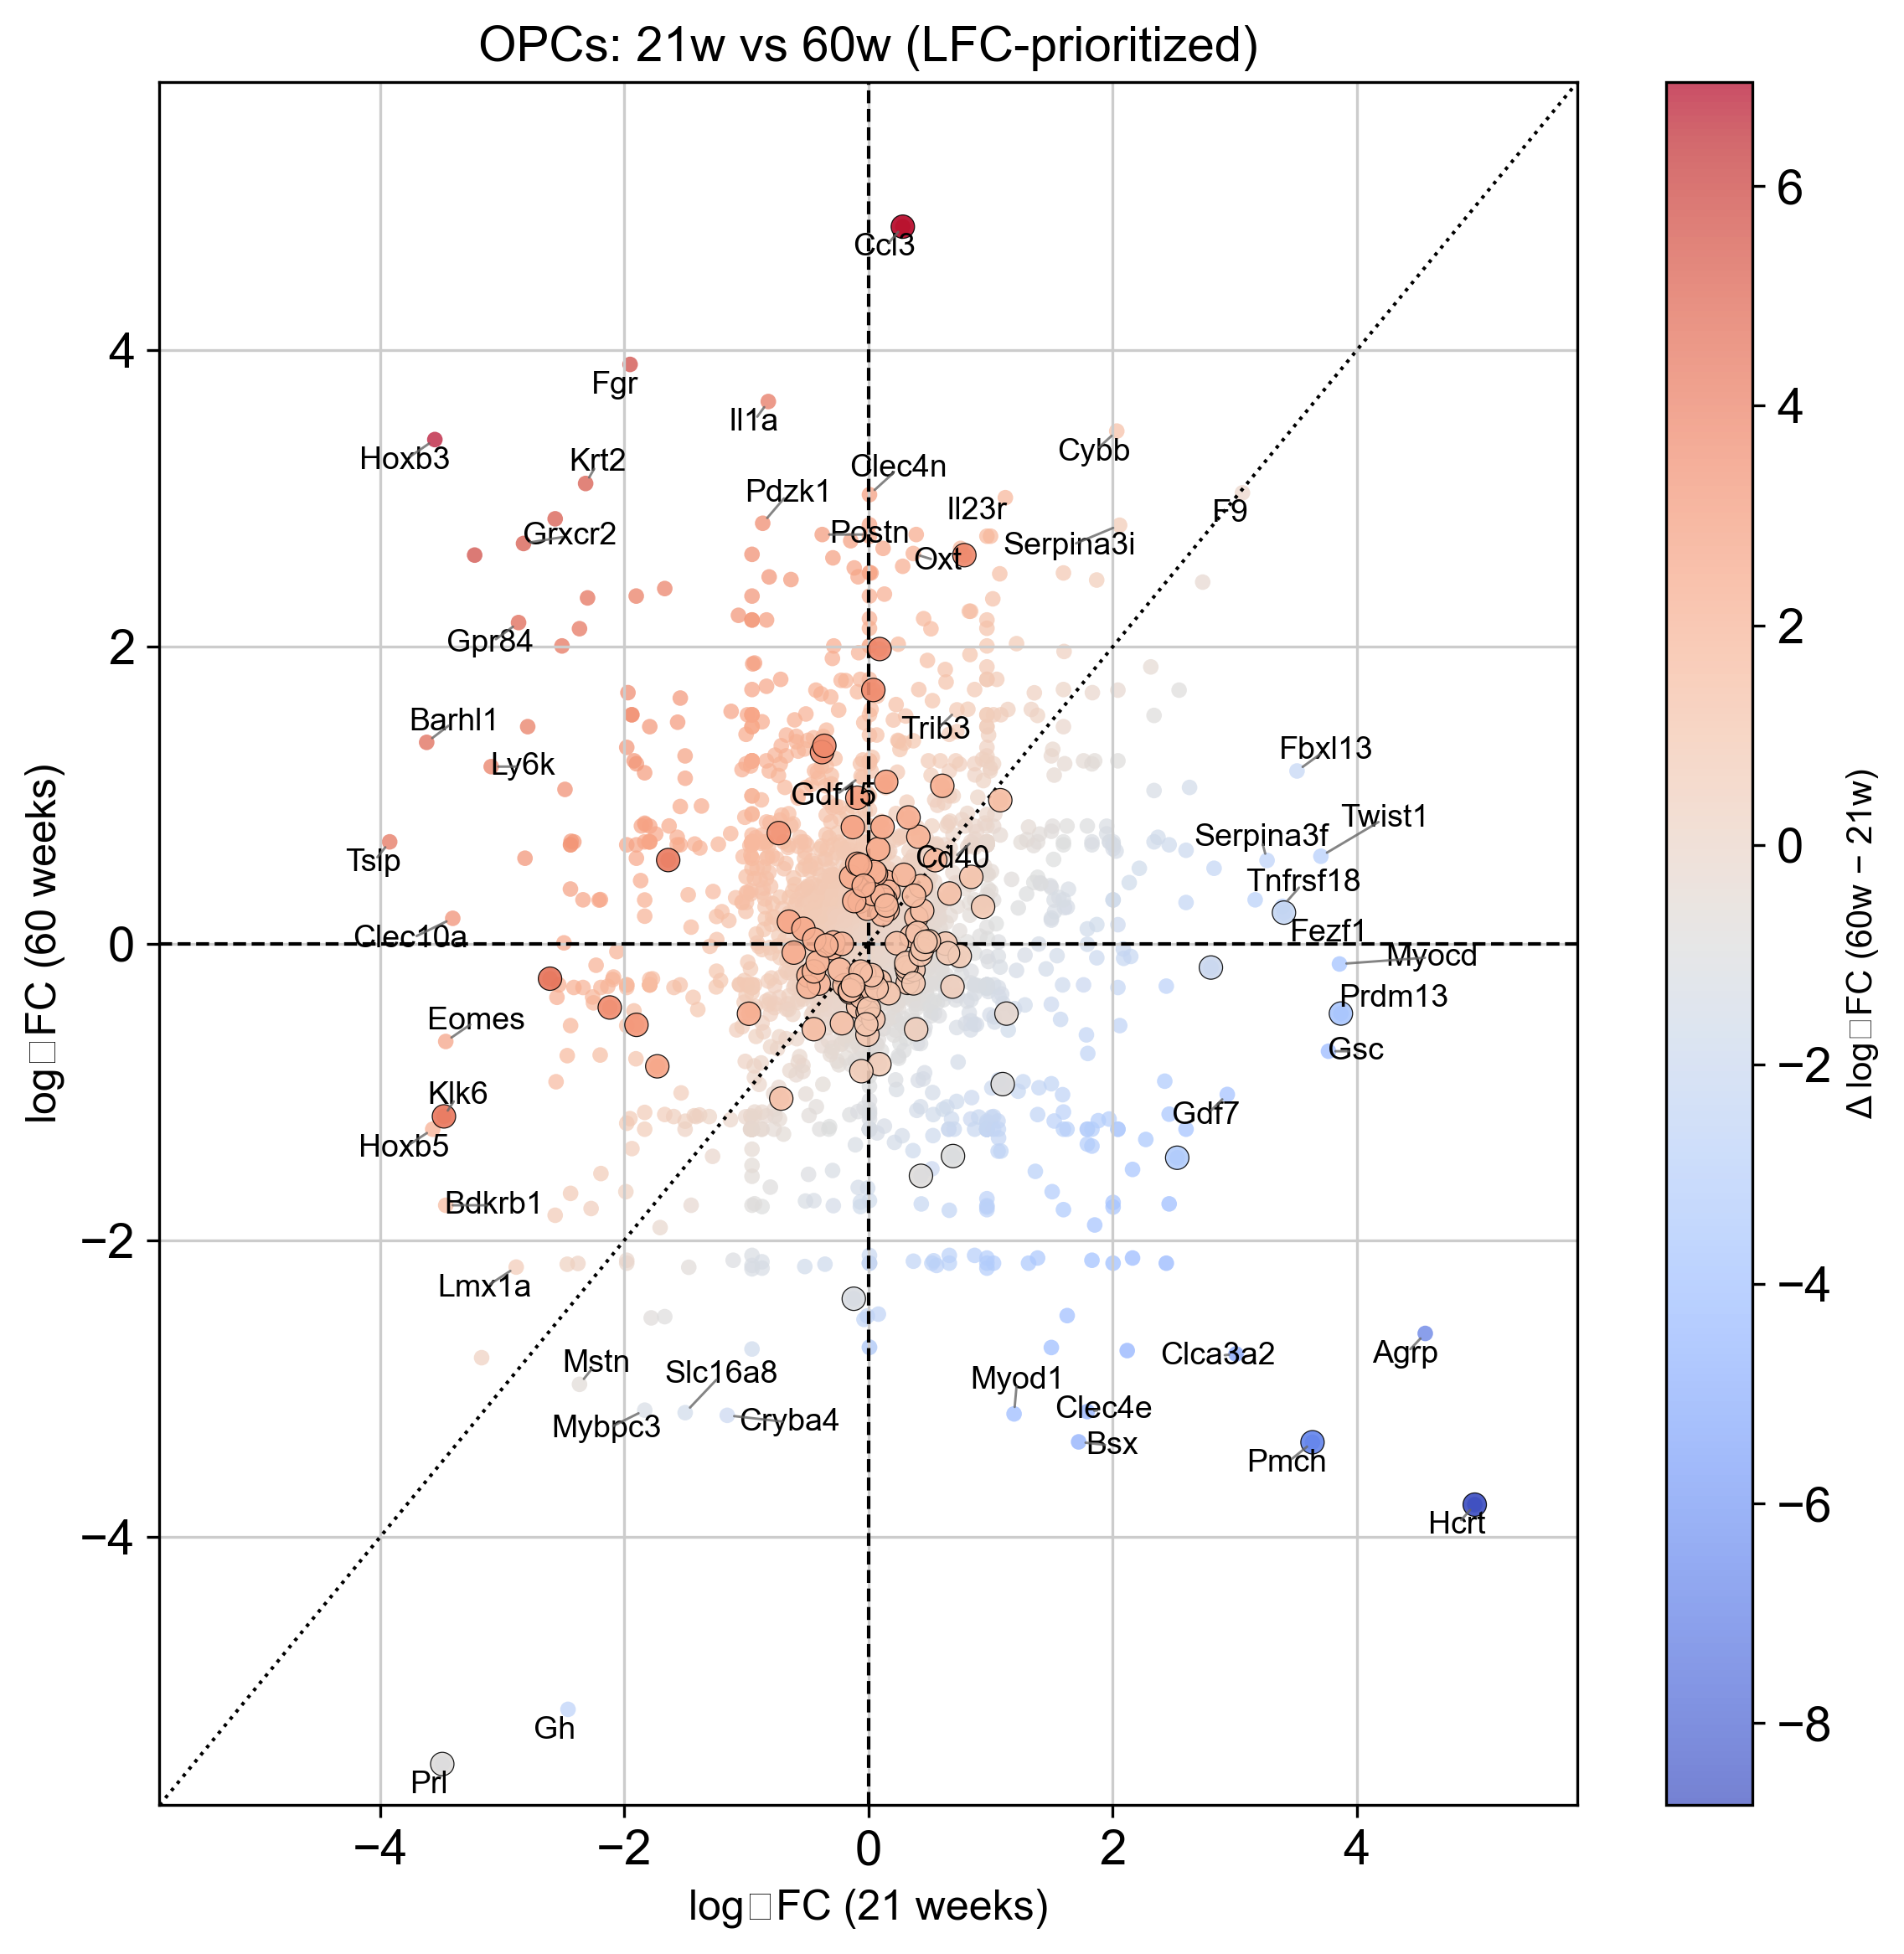

In [283]:
res21 = results["Oligodendrocytes precursor cells"]["simple_effects"]["21"]
res60 = results["Oligodendrocytes precursor cells"]["simple_effects"]["60"]

# Prioritize big fold-changes; modest weight on FDR
picks, top21, top60 = pick_top_per_age(
    res21, res60,
    q=0.25, top_n_each=20,
    lfc_col='log2FC_mtDSB_vs_control',
    padj_col='pvalue_mtDSB_vs_control',
    alpha_lfc=1.0,   # stronger effect-size priority
    beta_p=0.0,     # lighter FDR weight; set 0 for pure LFC-based
    force_lfc_min=0.0,          # only if |LFC| ≥ 2.5
    max_labels=100
)

df_comp = compare_lfc_scatter_colored_labels(
    res_early=res21,
    res_late=res60,
    highlight_genes=picks+['Trib3','Cd40','Gdf15'],
    title="OPCs: 21w vs 60w (LFC-prioritized)",
    top_n_delta=0  # labels come from 'picks' instead of ΔLFC auto-labels
)

dict_keys(['Mature oligodendrocytes', 'Telencephalon astrocytes', 'Microglia', 'Oligodendrocytes precursor cells', 'Olfactory astrocytes'])

## Save results

In [290]:
import os

def save_all_results(results, outdir="../../results"):
    """
    Save all DE results from the nested `results` dict into organized subfolders.
    Structure:
        outdir/
          └── <cell_type>/
                ├── simple_effect_age_<age>.csv
                ├── deltaLFC_<ageA>_vs_<ageB>.csv
    """
    os.makedirs(outdir, exist_ok=True)

    for ct, rdict in results.items():
        ct_dir = os.path.join(outdir, ct.replace(" ", "_"))
        os.makedirs(ct_dir, exist_ok=True)

        # --- Simple effects (mtDSB vs control per age) ---
        for age, df in rdict.get("simple_effects", {}).items():
            if df is not None:
                fname = f"simple_effect_age_{age}.csv"
                df.to_csv(os.path.join(ct_dir, fname))

        # --- Delta-LFC (interaction proxy between ages) ---
        for (a1, a2), df in rdict.get("deltas", {}).items():
            if df is not None:
                fname = f"deltaLFC_{a1}_vs_{a2}.csv"
                df.to_csv(os.path.join(ct_dir, fname))

        print(f"✅ Saved {ct} results to {ct_dir}")

In [291]:
save_all_results(results, outdir="../results/age")

✅ Saved Mature oligodendrocytes results to ../results/age/Mature_oligodendrocytes
✅ Saved Telencephalon astrocytes results to ../results/age/Telencephalon_astrocytes
✅ Saved Microglia results to ../results/age/Microglia
✅ Saved Oligodendrocytes precursor cells results to ../results/age/Oligodendrocytes_precursor_cells
✅ Saved Olfactory astrocytes results to ../results/age/Olfactory_astrocytes


In [122]:
adata.obs

View of AnnData object with n_obs × n_vars = 184678 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'